# Tracking How Influence Shifts in Social Networks
### A temporal graph analytics approach using PageRank, community detection, and node embeddings

---

We're using the **Bitcoin OTC trust network** from Stanford's SNAP — a real-world directed trust network where users rate each other from -10 (total distrust) to +10 (total trust). It has **5,881 nodes** and **35,592 timestamped edges**, spanning several years.

The idea: slice this data into temporal windows and watch how influence, communities, and network structure evolve over time.

**What we're doing:**
- Load a real temporal social network (Bitcoin OTC trust network from SNAP)
- Slice into 10 temporal snapshots based on timestamps
- Compute influence rankings using PageRank at each time step
- Detect communities with Louvain and track how they shift
- Learn node embeddings via Node2Vec
- Evaluate with NDCG, Kendall's τ, and NMI
- Visualize the whole story

**Dataset:** [soc-sign-bitcoinotc](https://snap.stanford.edu/data/soc-sign-bitcoinotc.html) — Stanford SNAP  
**Citation:** S. Kumar, F. Spezzano, V.S. Subrahmanian, C. Faloutsos. *Edge Weight Prediction in Weighted Signed Networks.* ICDM, 2016.

## Setup & Configuration

In [1]:
import os
import gzip
import random
import time
import warnings
import urllib.request
from collections import Counter
from datetime import datetime
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import networkx as nx
from community import community_louvain
from node2vec import Node2Vec

from scipy.stats import kendalltau
from scipy.spatial.distance import cosine
from scipy.linalg import orthogonal_procrustes
from sklearn.metrics import normalized_mutual_info_score
from sklearn.manifold import TSNE

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec
import seaborn as sns

%matplotlib inline

print('All imports loaded.')

All imports loaded.


In [2]:
RANDOM_SEED = 42
NUM_SNAPSHOTS = 10

# pagerank
PAGERANK_ALPHA = 0.85
PAGERANK_MAX_ITER = 200

# node2vec
NODE2VEC_DIMENSIONS = 64
NODE2VEC_WALK_LENGTH = 30
NODE2VEC_NUM_WALKS = 200
NODE2VEC_P = 1.0
NODE2VEC_Q = 1.0
NODE2VEC_WORKERS = 4
NODE2VEC_WINDOW = 10
NODE2VEC_EPOCHS = 5

# evaluation
NDCG_K = 10
GROUND_TRUTH_WEIGHTS = {'pagerank': 0.4, 'betweenness': 0.3, 'degree': 0.3}

# viz
VIS_SNAPSHOT_INDICES = [0, 4, 9]
TOP_N_HEATMAP = 50
TOP_N_DASHBOARD = 10
FIGURE_DPI = 150

# output
OUTPUT_DIR = os.path.join(os.getcwd(), 'output')
FIGURES_DIR = os.path.join(OUTPUT_DIR, 'figures')
DATA_DIR = os.path.join(os.getcwd(), 'data')
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(DATA_DIR, exist_ok=True)

# dark theme
plt.rcParams.update({
    'figure.facecolor': '#0d1117',
    'axes.facecolor': '#161b22',
    'axes.edgecolor': '#30363d',
    'axes.labelcolor': '#c9d1d9',
    'text.color': '#c9d1d9',
    'xtick.color': '#8b949e',
    'ytick.color': '#8b949e',
    'grid.color': '#21262d',
    'grid.alpha': 0.5,
    'font.family': 'sans-serif',
    'font.size': 11,
})

COMMUNITY_COLORS = [
    '#58a6ff', '#f78166', '#7ee787', '#d2a8ff', '#ff7b72',
    '#79c0ff', '#ffa657', '#56d4dd', '#f0883e', '#bc8cff',
    '#39d353', '#e3b341', '#ff9bce', '#a5d6ff', '#ffd33d',
    '#db61a2', '#8957e5', '#3fb950', '#f85149', '#6cb6ff',
]

print('Config ready.')

Config ready.


---
## Loading the Bitcoin OTC Trust Network

This is a who-trusts-whom network from the Bitcoin OTC marketplace. Users rate each other on a scale of -10 to +10. Every rating has a timestamp, so we can slice it into temporal snapshots and watch how trust (and influence) evolves.

- **5,881 nodes** (users), **35,592 edges** (trust ratings)
- Timestamps span from 2010 to 2016
- We'll treat it as undirected for community detection and convert edge ratings to weights

In [3]:
DATASET_URL = 'https://snap.stanford.edu/data/soc-sign-bitcoinotc.csv.gz'
DATASET_GZ = os.path.join(DATA_DIR, 'soc-sign-bitcoinotc.csv.gz')
DATASET_CSV = os.path.join(DATA_DIR, 'soc-sign-bitcoinotc.csv')

# download if we don't already have it
if not os.path.exists(DATASET_CSV):
    if not os.path.exists(DATASET_GZ):
        print(f'Downloading dataset from SNAP...')
        urllib.request.urlretrieve(DATASET_URL, DATASET_GZ)
        print(f'Downloaded to {DATASET_GZ}')
    
    # decompress
    print('Decompressing...')
    with gzip.open(DATASET_GZ, 'rt') as f_in:
        with open(DATASET_CSV, 'w') as f_out:
            f_out.write(f_in.read())
    print(f'Saved to {DATASET_CSV}')
else:
    print(f'Dataset already exists at {DATASET_CSV}')

# load it
edges_df = pd.read_csv(DATASET_CSV, header=None,
                        names=['source', 'target', 'rating', 'timestamp'])

print(f'\nLoaded {len(edges_df)} edges')
print(f'Unique nodes: {len(set(edges_df["source"]) | set(edges_df["target"]))}')
print(f'Rating range: [{edges_df["rating"].min()}, {edges_df["rating"].max()}]')
print(f'Time range: {datetime.fromtimestamp(edges_df["timestamp"].min())} to '
      f'{datetime.fromtimestamp(edges_df["timestamp"].max())}')
print(f'\nFirst few rows:')
edges_df.head()

Downloaded to c:\Users\ASUS\Documents\projects\something-graph\data\soc-sign-bitcoinotc.csv.gz
Decompressing...
Saved to c:\Users\ASUS\Documents\projects\something-graph\data\soc-sign-bitcoinotc.csv

Loaded 35592 edges
Unique nodes: 5881
Rating range: [-10, 10]
Time range: 2010-11-09 00:15:11.728360 to 2016-01-25 06:42:03.757280

First few rows:


,source,target,rating,timestamp
0,6,2,4,1.289242e+09
1,6,5,2,1.289242e+09
2,1,15,1,1.289243e+09
3,4,3,7,1.289245e+09
4,13,16,8,1.289254e+09


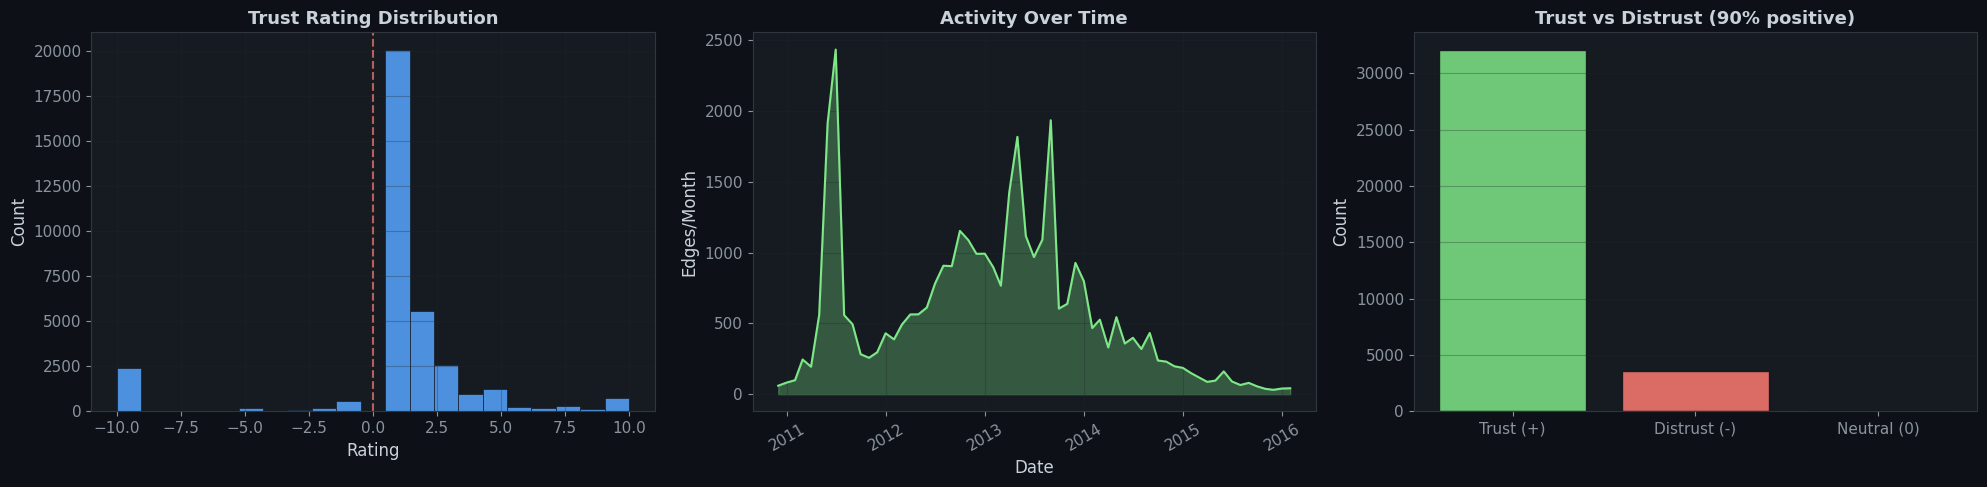

In [5]:
# quick look at the data
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# rating distribution
axes[0].hist(edges_df['rating'], bins=21, color='#58a6ff', alpha=0.85,
             edgecolor='#0d1117', linewidth=0.5)
axes[0].set_xlabel('Rating', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_title('Trust Rating Distribution', fontsize=13, fontweight='bold')
axes[0].axvline(0, color='#ff7b72', linestyle='--', alpha=0.7)
axes[0].grid(True, alpha=0.3)

# edges over time
edges_df['date'] = pd.to_datetime(edges_df['timestamp'], unit='s')
monthly = edges_df.set_index('date').resample('ME').size()
axes[1].fill_between(monthly.index, monthly.values, alpha=0.3, color='#7ee787')
axes[1].plot(monthly.index, monthly.values, color='#7ee787', linewidth=1.5)
axes[1].set_xlabel('Date', fontsize=12)
axes[1].set_ylabel('Edges/Month', fontsize=12)
axes[1].set_title('Activity Over Time', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].tick_params(axis='x', rotation=30)

# positive vs negative ratings
pos = (edges_df['rating'] > 0).sum()
neg = (edges_df['rating'] < 0).sum()
neu = (edges_df['rating'] == 0).sum()
axes[2].bar(['Trust (+)', 'Distrust (-)', 'Neutral (0)'], [pos, neg, neu],
            color=['#7ee787', '#ff7b72', '#8b949e'], alpha=0.85,
            edgecolor='#0d1117', linewidth=1)
axes[2].set_ylabel('Count', fontsize=12)
axes[2].set_title(f'Trust vs Distrust ({pos/(pos+neg)*100:.0f}% positive)', fontsize=13, fontweight='bold')
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, 'dataset_overview.png'), dpi=FIGURE_DPI,
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

---
## Building Temporal Snapshots

We split the full time range into 10 equal windows. Each snapshot is **cumulative** — it includes all edges from the beginning up to that window's cutoff. This way we can watch the network grow and see how influence shifts as new users and connections appear.

In [6]:
def build_temporal_snapshots(edges_df, num_snapshots=NUM_SNAPSHOTS):
    """Slice the edge list into cumulative temporal snapshots."""
    edges_sorted = edges_df.sort_values('timestamp')
    t_min = edges_sorted['timestamp'].min()
    t_max = edges_sorted['timestamp'].max()
    
    # equal-width time windows
    boundaries = np.linspace(t_min, t_max, num_snapshots + 1)
    
    snapshots = []
    for i in range(num_snapshots):
        cutoff = boundaries[i + 1]
        window_edges = edges_sorted[edges_sorted['timestamp'] <= cutoff]
        
        G = nx.Graph()  # undirected for community detection
        
        for _, row in window_edges.iterrows():
            src, tgt = int(row['source']), int(row['target'])
            rating = row['rating']
            # use absolute rating as weight — both trust and distrust = interaction
            weight = abs(rating) if rating != 0 else 1
            
            if G.has_edge(src, tgt):
                # keep the stronger connection
                G[src][tgt]['weight'] = max(G[src][tgt]['weight'], weight)
            else:
                G.add_edge(src, tgt, weight=weight)
        
        # mark all nodes as active
        for node in G.nodes():
            G.nodes[node]['active'] = True
        
        cutoff_date = datetime.fromtimestamp(cutoff).strftime('%Y-%m')
        print(f't={i}: {G.number_of_nodes():>5d} nodes, {G.number_of_edges():>5d} edges  '
              f'(up to {cutoff_date})')
        snapshots.append(G)
    
    return snapshots

print('Building temporal snapshots...\n')
t0 = time.time()
snapshots = build_temporal_snapshots(edges_df)
print(f'\nDone in {time.time()-t0:.1f}s — {len(snapshots)} snapshots ready.')

Building temporal snapshots...

t=0:   570 nodes,  1378 edges  (up to 2011-05)
t=1:  1555 nodes,  4159 edges  (up to 2011-11)
t=2:  2070 nodes,  5983 edges  (up to 2012-06)
t=3:  3040 nodes,  9729 edges  (up to 2012-12)
t=4:  4308 nodes, 14064 edges  (up to 2013-06)
t=5:  5137 nodes, 18092 edges  (up to 2013-12)
t=6:  5558 nodes, 19890 edges  (up to 2014-07)
t=7:  5757 nodes, 20893 edges  (up to 2015-01)
t=8:  5844 nodes, 21314 edges  (up to 2015-07)
t=9:  5881 nodes, 21492 edges  (up to 2016-01)

Done in 3.7s — 10 snapshots ready.


### Degree distribution
Real social networks should be scale-free — let's see if that holds

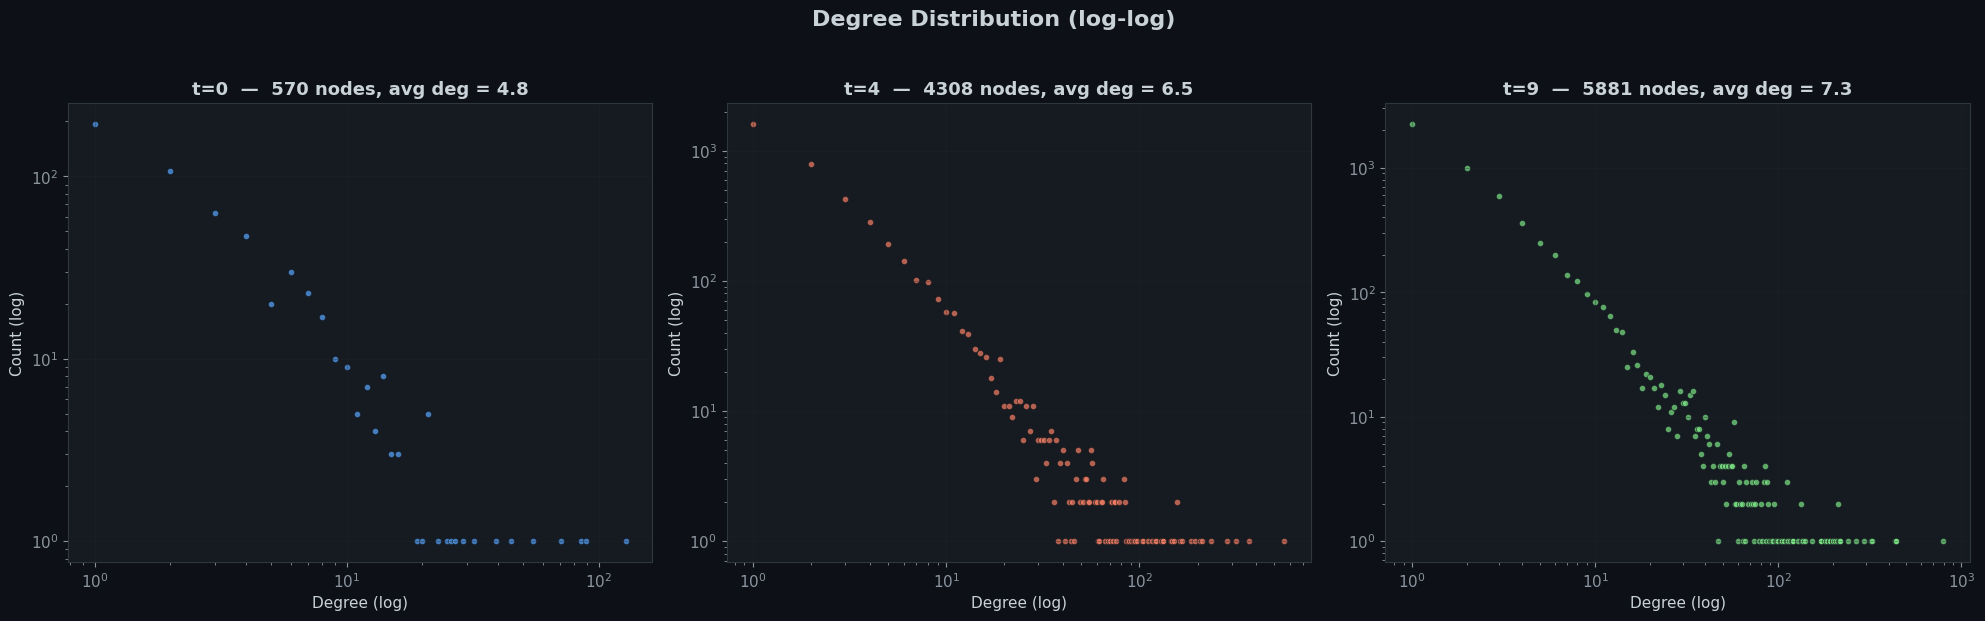

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for idx, t in enumerate([0, 4, 9]):
    ax = axes[idx]
    G = snapshots[t]
    degs = [G.degree(n) for n in G.nodes()]
    
    deg_count = pd.Series(degs).value_counts().sort_index()
    ax.scatter(deg_count.index, deg_count.values, s=20, alpha=0.7,
               color=COMMUNITY_COLORS[idx], edgecolors='#0d1117', linewidths=0.5)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Degree (log)', fontsize=11)
    ax.set_ylabel('Count (log)', fontsize=11)
    ax.set_title(f't={t}  —  {G.number_of_nodes()} nodes, avg deg = {np.mean(degs):.1f}',
                 fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3)

fig.suptitle('Degree Distribution (log-log)', fontsize=16, fontweight='bold', y=1.03)
plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, 'degree_distribution.png'), dpi=FIGURE_DPI,
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

### How the graph grows over time

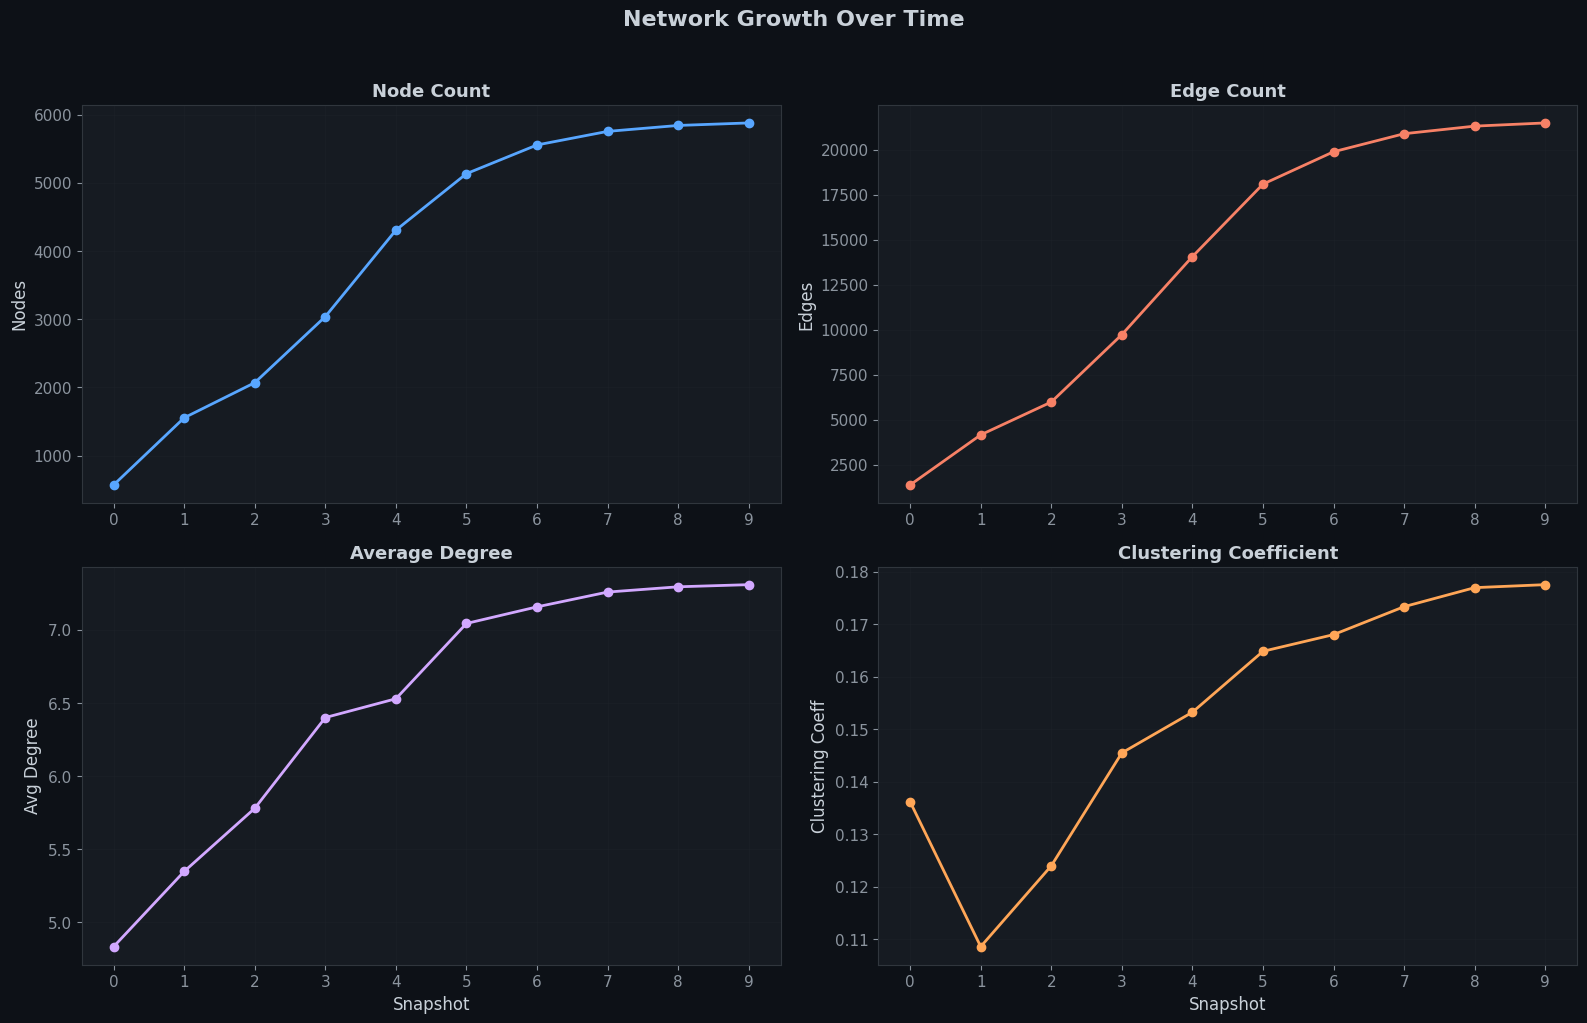

,t,nodes,edges,density,avg_degree,avg_clustering
0,0,570,1378,0.008498,4.835088,0.136136
1,1,1555,4159,0.003442,5.349196,0.108561
2,2,2070,5983,0.002794,5.780676,0.123951
3,3,3040,9729,0.002106,6.400658,0.145463
4,4,4308,14064,0.001516,6.529248,0.153210
5,5,5137,18092,0.001371,7.043800,0.164807
6,6,5558,19890,0.001288,7.157251,0.167987
7,7,5757,20893,0.001261,7.258294,0.173311
8,8,5844,21314,0.001248,7.294319,0.176934
9,9,5881,21492,0.001243,7.308961,0.177504


In [8]:
stats = []
for t, G in enumerate(snapshots):
    stats.append({
        't': t,
        'nodes': G.number_of_nodes(),
        'edges': G.number_of_edges(),
        'density': nx.density(G),
        'avg_degree': np.mean([G.degree(n) for n in G.nodes()]) if G.number_of_nodes() > 0 else 0,
        'avg_clustering': nx.average_clustering(G) if G.number_of_nodes() > 2 else 0,
    })
stats_df = pd.DataFrame(stats)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0,0].plot(stats_df['t'], stats_df['nodes'], 'o-', color='#58a6ff', linewidth=2)
axes[0,0].set_ylabel('Nodes', fontsize=12)
axes[0,0].set_title('Node Count', fontsize=13, fontweight='bold')
axes[0,0].grid(True, alpha=0.3)

axes[0,1].plot(stats_df['t'], stats_df['edges'], 'o-', color='#f78166', linewidth=2)
axes[0,1].set_ylabel('Edges', fontsize=12)
axes[0,1].set_title('Edge Count', fontsize=13, fontweight='bold')
axes[0,1].grid(True, alpha=0.3)

axes[1,0].plot(stats_df['t'], stats_df['avg_degree'], 'o-', color='#d2a8ff', linewidth=2)
axes[1,0].set_ylabel('Avg Degree', fontsize=12)
axes[1,0].set_xlabel('Snapshot', fontsize=12)
axes[1,0].set_title('Average Degree', fontsize=13, fontweight='bold')
axes[1,0].grid(True, alpha=0.3)

axes[1,1].plot(stats_df['t'], stats_df['avg_clustering'], 'o-', color='#ffa657', linewidth=2)
axes[1,1].set_ylabel('Clustering Coeff', fontsize=12)
axes[1,1].set_xlabel('Snapshot', fontsize=12)
axes[1,1].set_title('Clustering Coefficient', fontsize=13, fontweight='bold')
axes[1,1].grid(True, alpha=0.3)

for ax in axes.flat:
    ax.set_xticks(range(NUM_SNAPSHOTS))

fig.suptitle('Network Growth Over Time', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, 'graph_stats_over_time.png'), dpi=FIGURE_DPI,
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

stats_df

---
## Finding the Influential Nodes

Two things here:
1. **PageRank** — recursive influence: who's connected to other important people?
2. **Louvain communities** — natural groupings by modularity maximization

Ground truth = 40% PageRank + 30% betweenness + 30% degree centrality (blended score)

In [9]:
def get_active_subgraph(G):
    active = [n for n in G.nodes() if G.nodes[n].get('active', True)]
    return G.subgraph(active).copy()


def compute_pagerank(G):
    H = get_active_subgraph(G)
    if H.number_of_nodes() == 0:
        return {}
    return nx.pagerank(H, alpha=PAGERANK_ALPHA, max_iter=PAGERANK_MAX_ITER, tol=1e-06)


def detect_communities(G):
    H = get_active_subgraph(G)
    if H.number_of_nodes() == 0:
        return {}
    return community_louvain.best_partition(H, random_state=RANDOM_SEED)


def compute_centrality_metrics(G):
    H = get_active_subgraph(G)
    if H.number_of_nodes() == 0:
        return {'degree': {}, 'betweenness': {}, 'closeness': {}}
    # sample betweenness to keep it fast
    return {
        'degree': nx.degree_centrality(H),
        'betweenness': nx.betweenness_centrality(H, k=min(100, H.number_of_nodes())),
        'closeness': nx.closeness_centrality(H),
    }


def compute_composite_ground_truth(G):
    """Blended influence score for evaluation."""
    pr = compute_pagerank(G)
    centrality = compute_centrality_metrics(G)
    if not pr:
        return {}
    
    def normalize(scores):
        vals = np.array(list(scores.values()))
        if vals.max() == vals.min():
            return {k: 0.5 for k in scores}
        return {k: (v - vals.min()) / (vals.max() - vals.min()) for k, v in scores.items()}
    
    pr_n = normalize(pr)
    deg_n = normalize(centrality['degree'])
    bet_n = normalize(centrality['betweenness'])
    w = GROUND_TRUTH_WEIGHTS
    
    return {
        node: w['pagerank']*pr_n.get(node, 0) + w['degree']*deg_n.get(node, 0) + w['betweenness']*bet_n.get(node, 0)
        for node in pr.keys()
    }

In [10]:
print('Running PageRank and community detection...\n')
t0 = time.time()

pagerank_history = []
community_history = []

for t, G in enumerate(snapshots):
    pr = compute_pagerank(G)
    comms = detect_communities(G)
    pagerank_history.append(pr)
    community_history.append(comms)
    num_comms = len(set(comms.values())) if comms else 0
    top_pr = max(pr.values()) if pr else 0
    print(f't={t}: top PR = {top_pr:.6f}, {num_comms} communities')

influence_df = pd.concat(
    [pd.Series(pr, name=f't{t}') for t, pr in enumerate(pagerank_history)],
    axis=1
).fillna(0)

print(f'\nDone in {time.time()-t0:.1f}s')
print(f'Influence matrix: {influence_df.shape[0]} nodes x {influence_df.shape[1]} snapshots')

Running PageRank and community detection...

t=0: top PR = 0.052182, 15 communities
t=1: top PR = 0.024842, 21 communities
t=2: top PR = 0.019147, 22 communities
t=3: top PR = 0.019462, 22 communities
t=4: top PR = 0.020576, 29 communities
t=5: top PR = 0.019668, 24 communities
t=6: top PR = 0.019303, 24 communities
t=7: top PR = 0.019848, 20 communities
t=8: top PR = 0.020408, 25 communities
t=9: top PR = 0.020734, 27 communities

Done in 3.7s
Influence matrix: 5881 nodes x 10 snapshots


### PageRank distribution — how is influence spread?

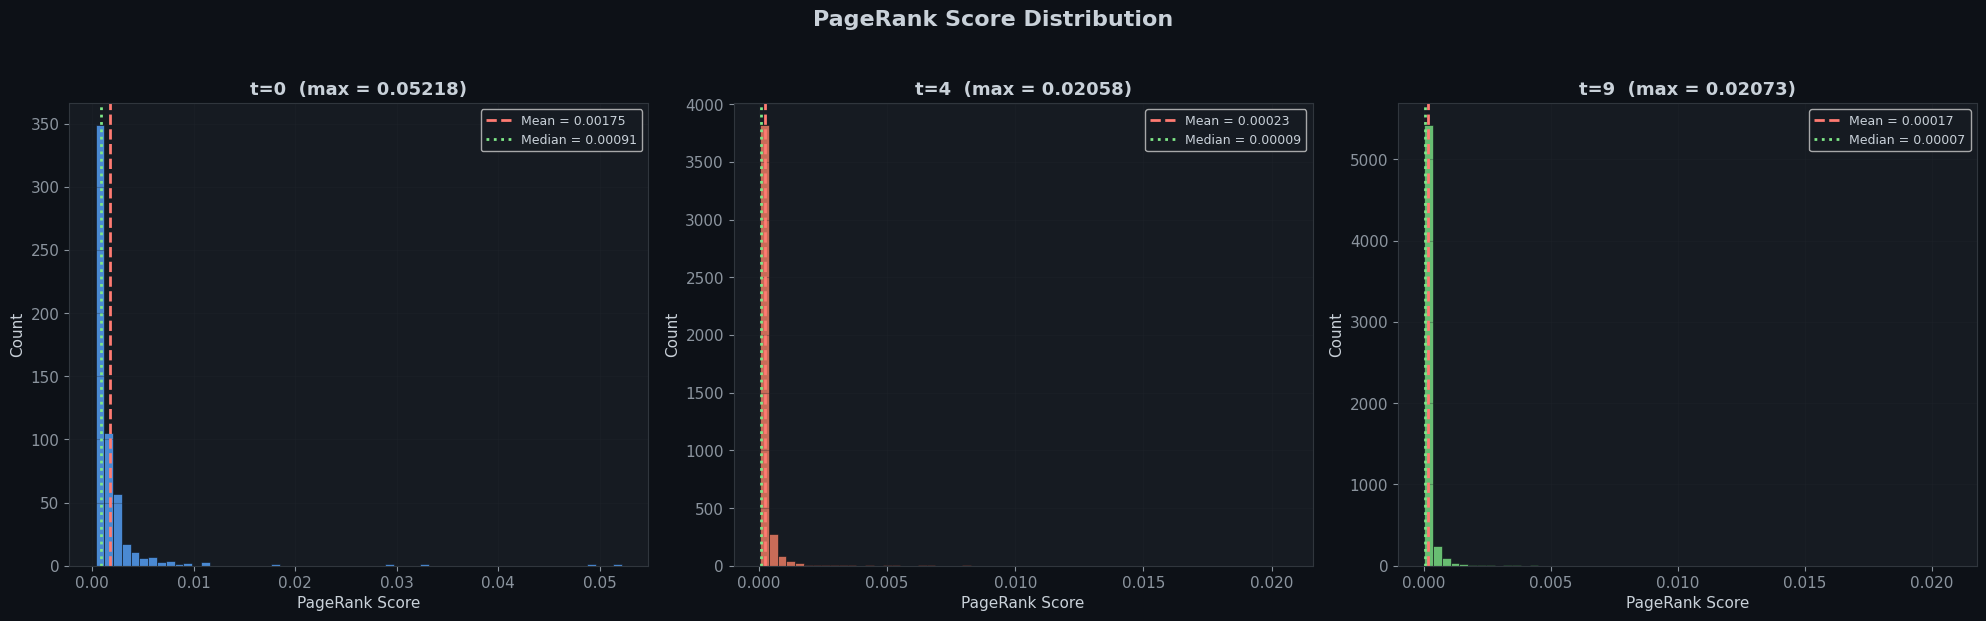

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for idx, t in enumerate([0, 4, 9]):
    ax = axes[idx]
    pr_vals = list(pagerank_history[t].values())
    
    ax.hist(pr_vals, bins=60, color=COMMUNITY_COLORS[idx], alpha=0.8,
            edgecolor='#0d1117', linewidth=0.5)
    ax.axvline(np.mean(pr_vals), color='#ff7b72', linestyle='--', linewidth=2,
               label=f'Mean = {np.mean(pr_vals):.5f}')
    ax.axvline(np.median(pr_vals), color='#7ee787', linestyle=':', linewidth=2,
               label=f'Median = {np.median(pr_vals):.5f}')
    ax.set_xlabel('PageRank Score', fontsize=11)
    ax.set_ylabel('Count', fontsize=11)
    ax.set_title(f't={t}  (max = {max(pr_vals):.5f})', fontsize=13, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

fig.suptitle('PageRank Score Distribution', fontsize=16, fontweight='bold', y=1.03)
plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, 'pagerank_distribution.png'), dpi=FIGURE_DPI,
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

### Degree vs PageRank

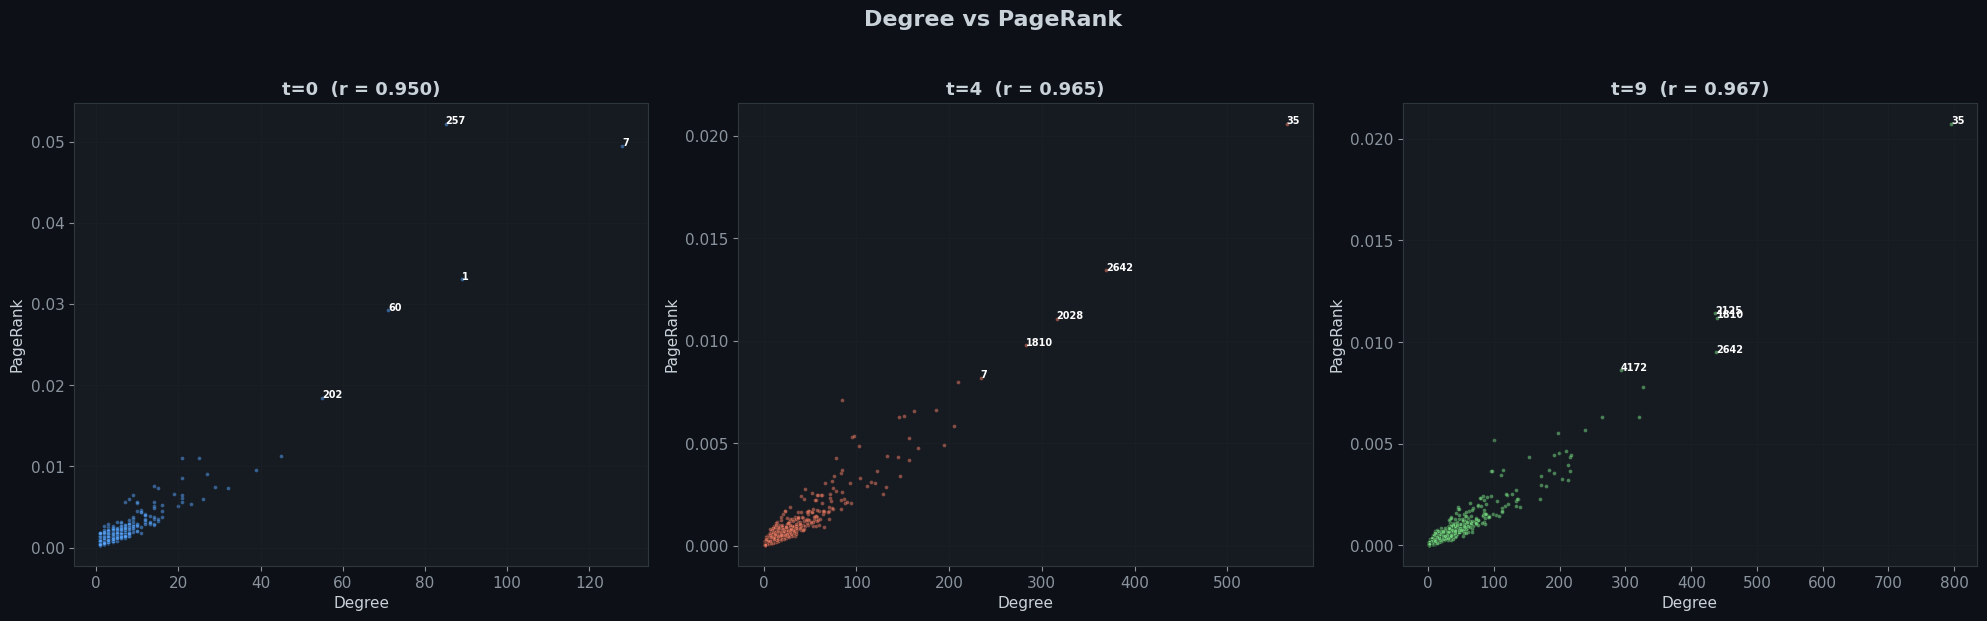

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for idx, t in enumerate([0, 4, 9]):
    ax = axes[idx]
    G = snapshots[t]
    pr = pagerank_history[t]
    nodes = list(pr.keys())
    degrees = [G.degree(n) for n in nodes]
    pr_vals = [pr[n] for n in nodes]
    
    ax.scatter(degrees, pr_vals, s=8, alpha=0.5, color=COMMUNITY_COLORS[idx],
               edgecolors='#0d1117', linewidths=0.3)
    
    # label top 5 by pagerank
    top5 = sorted(nodes, key=lambda n: pr[n], reverse=True)[:5]
    for n in top5:
        ax.annotate(str(n), (G.degree(n), pr[n]),
                    fontsize=7, color='#ffffff', fontweight='bold')
    
    corr = np.corrcoef(degrees, pr_vals)[0, 1]
    ax.set_xlabel('Degree', fontsize=11)
    ax.set_ylabel('PageRank', fontsize=11)
    ax.set_title(f't={t}  (r = {corr:.3f})', fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3)

fig.suptitle('Degree vs PageRank', fontsize=16, fontweight='bold', y=1.03)
plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, 'degree_vs_pagerank.png'), dpi=FIGURE_DPI,
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

### Centrality correlation heatmap

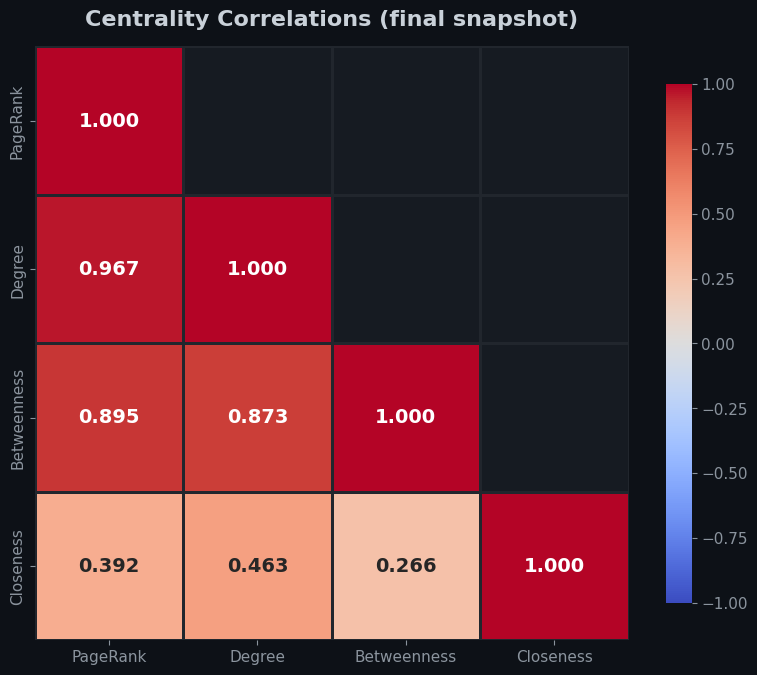

In [13]:
# use the last snapshot — most data
cent = compute_centrality_metrics(snapshots[-1])
pr_last = pagerank_history[-1]

common_nodes = sorted(set(pr_last.keys()) & set(cent['degree'].keys()))
cent_df = pd.DataFrame({
    'PageRank': [pr_last[n] for n in common_nodes],
    'Degree': [cent['degree'][n] for n in common_nodes],
    'Betweenness': [cent['betweenness'][n] for n in common_nodes],
    'Closeness': [cent['closeness'][n] for n in common_nodes],
})

fig, ax = plt.subplots(figsize=(8, 7))
corr_matrix = cent_df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm',
            mask=mask, ax=ax, linewidths=2, linecolor='#21262d',
            vmin=-1, vmax=1, square=True,
            annot_kws={'fontsize': 14, 'fontweight': 'bold'},
            cbar_kws={'shrink': 0.8})

ax.set_title('Centrality Correlations (final snapshot)', fontsize=16, fontweight='bold', pad=15)
plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, 'centrality_correlation.png'), dpi=FIGURE_DPI,
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

### Tracking specific nodes over time
Following the top 10 from the final snapshot back through time

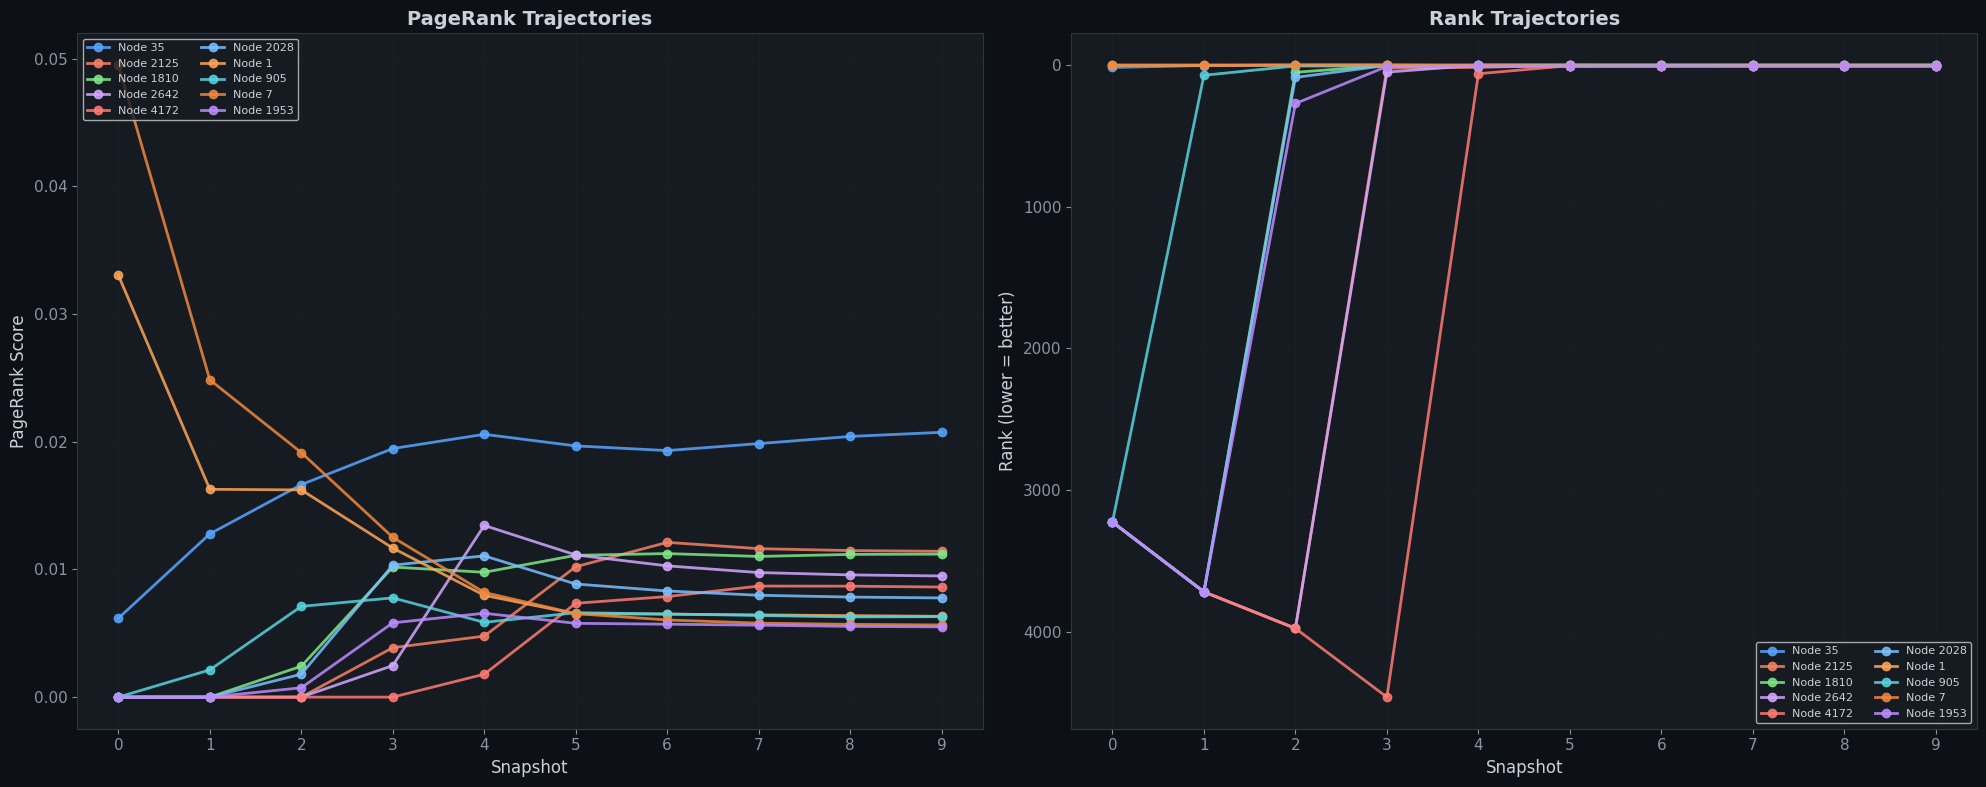

In [14]:
# pick top 10 from the last snapshot (they have enough history)
top10 = sorted(pagerank_history[-1], key=lambda n: pagerank_history[-1][n], reverse=True)[:10]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

for i, node in enumerate(top10):
    scores = [pagerank_history[t].get(node, 0) for t in range(NUM_SNAPSHOTS)]
    ax1.plot(range(NUM_SNAPSHOTS), scores, 'o-', color=COMMUNITY_COLORS[i],
             linewidth=2, markersize=6, label=f'Node {node}', alpha=0.85)

ax1.set_xlabel('Snapshot', fontsize=12)
ax1.set_ylabel('PageRank Score', fontsize=12)
ax1.set_title('PageRank Trajectories', fontsize=14, fontweight='bold')
ax1.legend(fontsize=8, loc='upper left', ncol=2)
ax1.grid(True, alpha=0.3)
ax1.set_xticks(range(NUM_SNAPSHOTS))

# rank trajectories
rank_df = influence_df.rank(ascending=False)
for i, node in enumerate(top10):
    if node in rank_df.index:
        ranks = [rank_df.loc[node, f't{t}'] if f't{t}' in rank_df.columns else np.nan
                 for t in range(NUM_SNAPSHOTS)]
        ax2.plot(range(NUM_SNAPSHOTS), ranks, 'o-', color=COMMUNITY_COLORS[i],
                 linewidth=2, markersize=6, label=f'Node {node}', alpha=0.85)

ax2.set_xlabel('Snapshot', fontsize=12)
ax2.set_ylabel('Rank (lower = better)', fontsize=12)
ax2.set_title('Rank Trajectories', fontsize=14, fontweight='bold')
ax2.invert_yaxis()
ax2.legend(fontsize=8, loc='lower right', ncol=2)
ax2.grid(True, alpha=0.3)
ax2.set_xticks(range(NUM_SNAPSHOTS))

plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, 'top_node_trajectories.png'), dpi=FIGURE_DPI,
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

---
## Node2Vec Embeddings

Biased random walks + Word2Vec gives each node a 64-dimensional fingerprint based on its local structure. We train per snapshot and align using Procrustes so we can compare across time.

In [27]:
def compute_node2vec_embeddings(G, snapshot_index=0):
    H = get_active_subgraph(G)
    if H.number_of_nodes() < 10:
        return {}
    
    # need connected graph
    if not nx.is_connected(H):
        largest_cc = max(nx.connected_components(H), key=len)
        H = H.subgraph(largest_cc).copy()
    
    print(f'  Training Node2Vec for t={snapshot_index} ({H.number_of_nodes()} nodes)...')
    
    node2vec = Node2Vec(
        H, dimensions=NODE2VEC_DIMENSIONS,
        walk_length=NODE2VEC_WALK_LENGTH, num_walks=NODE2VEC_NUM_WALKS,
        p=NODE2VEC_P, q=NODE2VEC_Q,
        workers=NODE2VEC_WORKERS, seed=RANDOM_SEED + snapshot_index,
        quiet=True,
    )
    model = node2vec.fit(window=NODE2VEC_WINDOW, min_count=1, batch_words=4, epochs=NODE2VEC_EPOCHS)
    
    embeddings = {}
    for node in H.nodes():
        try:
            embeddings[node] = model.wv[str(node)]
        except KeyError:
            continue
    return embeddings


def align_embeddings_procrustes(emb_ref, emb_target):
    common = sorted(set(emb_ref.keys()) & set(emb_target.keys()))
    if len(common) < 10:
        return emb_target
    ref_mat = np.array([emb_ref[n] for n in common])
    tgt_mat = np.array([emb_target[n] for n in common])
    R, _ = orthogonal_procrustes(tgt_mat, ref_mat)
    return {node: vec @ R for node, vec in emb_target.items()}


def compute_embedding_drift(emb_t1, emb_t2):
    common = set(emb_t1.keys()) & set(emb_t2.keys())
    drift = {}
    for node in common:
        d = cosine(emb_t1[node], emb_t2[node])
        drift[node] = d if not np.isnan(d) else 0.0
    return drift


def reduce_embeddings_tsne(embeddings, perplexity=30):
    nodes = sorted(embeddings.keys())
    vectors = np.array([embeddings[n] for n in nodes])
    effective_perp = min(perplexity, max(5, len(nodes) // 4))
    tsne = TSNE(n_components=2, perplexity=effective_perp,
                random_state=RANDOM_SEED, max_iter=1000,
                learning_rate='auto', init='pca')
    coords = tsne.fit_transform(vectors)
    return nodes, coords

In [16]:
print('Computing Node2Vec embeddings (this takes a while)...\n')
t0 = time.time()

embeddings_all = []
for t, G in enumerate(snapshots):
    emb = compute_node2vec_embeddings(G, snapshot_index=t)
    embeddings_all.append(emb)

# align to first snapshot's space
if embeddings_all[0]:
    ref = embeddings_all[0]
    for t in range(1, len(embeddings_all)):
        if embeddings_all[t]:
            embeddings_all[t] = align_embeddings_procrustes(ref, embeddings_all[t])
            print(f'  Aligned t={t}')

if embeddings_all[0] and embeddings_all[-1]:
    drift = compute_embedding_drift(embeddings_all[0], embeddings_all[-1])
    print(f'\nMean drift (t=0 -> t={NUM_SNAPSHOTS-1}): {np.mean(list(drift.values())):.4f}')

print(f'Done in {time.time()-t0:.1f}s')

Computing Node2Vec embeddings (this takes a while)...

  Training Node2Vec for t=0 (568 nodes)...
  Training Node2Vec for t=1 (1555 nodes)...
  Training Node2Vec for t=2 (2070 nodes)...
  Training Node2Vec for t=3 (3038 nodes)...
  Training Node2Vec for t=4 (4302 nodes)...
  Training Node2Vec for t=5 (5133 nodes)...
  Training Node2Vec for t=6 (5554 nodes)...
  Training Node2Vec for t=7 (5753 nodes)...
  Training Node2Vec for t=8 (5840 nodes)...
  Training Node2Vec for t=9 (5875 nodes)...
  Aligned t=1
  Aligned t=2
  Aligned t=3
  Aligned t=4
  Aligned t=5
  Aligned t=6
  Aligned t=7
  Aligned t=8
  Aligned t=9

Mean drift (t=0 -> t=9): 0.2446
Done in 2522.3s


---
## Evaluating the Rankings

| Metric | What it tells us |
|--------|------------------|
| **NDCG@10** | How well does PageRank alone rank the top nodes vs our blended ground truth? |
| **Kendall's τ** | Are the rankings stable between consecutive snapshots? |
| **NMI** | Do communities stay consistent over time? |

In [17]:
def compute_ndcg(predicted, ground_truth, k=NDCG_K):
    common = set(predicted.keys()) & set(ground_truth.keys())
    if len(common) < k:
        k = len(common)
    if k == 0:
        return 0.0
    pred_ranking = sorted(common, key=lambda n: predicted[n], reverse=True)[:k]
    dcg = sum(ground_truth.get(node, 0) / np.log2(i + 2) for i, node in enumerate(pred_ranking))
    ideal_ranking = sorted(common, key=lambda n: ground_truth[n], reverse=True)[:k]
    idcg = sum(ground_truth.get(node, 0) / np.log2(i + 2) for i, node in enumerate(ideal_ranking))
    return dcg / idcg if idcg > 0 else 0.0


def compute_kendall_tau(r1, r2):
    common = sorted(set(r1.keys()) & set(r2.keys()))
    if len(common) < 5:
        return 0.0
    tau, _ = kendalltau([r1[n] for n in common], [r2[n] for n in common])
    return tau if not np.isnan(tau) else 0.0


def compute_nmi(c1, c2):
    common = sorted(set(c1.keys()) & set(c2.keys()))
    if len(common) < 5:
        return 0.0
    return normalized_mutual_info_score([c1[n] for n in common], [c2[n] for n in common])

In [18]:
print('Running evaluation...\n')

ndcg_scores = []
kendall_tau_scores = []
nmi_scores = []

for t, G in enumerate(snapshots):
    gt = compute_composite_ground_truth(G)
    ndcg = compute_ndcg(pagerank_history[t], gt)
    ndcg_scores.append(ndcg)
    print(f't={t}: NDCG@{NDCG_K} = {ndcg:.4f}')

print()
for t in range(1, len(snapshots)):
    tau = compute_kendall_tau(pagerank_history[t-1], pagerank_history[t])
    nmi = compute_nmi(community_history[t-1], community_history[t])
    kendall_tau_scores.append(tau)
    nmi_scores.append(nmi)
    print(f't={t-1} -> t={t}: Kendall tau = {tau:.4f}, NMI = {nmi:.4f}')

eval_rows = []
for t in range(len(snapshots)):
    eval_rows.append({
        'snapshot': t,
        'ndcg': ndcg_scores[t],
        'kendall_tau': kendall_tau_scores[t-1] if t > 0 else np.nan,
        'nmi': nmi_scores[t-1] if t > 0 else np.nan,
        'num_nodes': snapshots[t].number_of_nodes(),
        'num_edges': snapshots[t].number_of_edges(),
        'num_communities': len(set(community_history[t].values())) if community_history[t] else 0,
    })

summary_df = pd.DataFrame(eval_rows)

eval_results = {
    'ndcg_scores': ndcg_scores,
    'kendall_tau_scores': kendall_tau_scores,
    'nmi_scores': nmi_scores,
    'summary_df': summary_df,
}

print(f'\n{"="*50}')
print(f'Mean NDCG@{NDCG_K}:  {np.mean(ndcg_scores):.4f}')
print(f'Mean Kendall tau: {np.mean(kendall_tau_scores):.4f}')
print(f'Mean NMI:         {np.mean(nmi_scores):.4f}')
print(f'{"="*50}')

Running evaluation...

t=0: NDCG@10 = 0.9581
t=1: NDCG@10 = 0.9761
t=2: NDCG@10 = 0.9944
t=3: NDCG@10 = 0.9981
t=4: NDCG@10 = 0.9818
t=5: NDCG@10 = 0.9800
t=6: NDCG@10 = 0.9962
t=7: NDCG@10 = 0.9998
t=8: NDCG@10 = 0.9974
t=9: NDCG@10 = 0.9949

t=0 -> t=1: Kendall tau = 0.6729, NMI = 0.4469
t=1 -> t=2: Kendall tau = 0.9159, NMI = 0.6061
t=2 -> t=3: Kendall tau = 0.8782, NMI = 0.4775
t=3 -> t=4: Kendall tau = 0.8965, NMI = 0.5342
t=4 -> t=5: Kendall tau = 0.9196, NMI = 0.6332
t=5 -> t=6: Kendall tau = 0.9642, NMI = 0.6131
t=6 -> t=7: Kendall tau = 0.9773, NMI = 0.6717
t=7 -> t=8: Kendall tau = 0.9896, NMI = 0.7171
t=8 -> t=9: Kendall tau = 0.9949, NMI = 0.7157

Mean NDCG@10:  0.9877
Mean Kendall tau: 0.9121
Mean NMI:         0.6017


---
## All the Visualizations

In [19]:
def _comm_color_map(partition):
    unique = sorted(set(partition.values()))
    return {c: COMMUNITY_COLORS[i % len(COMMUNITY_COLORS)] for i, c in enumerate(unique)}

### Network Snapshots
Node size = PageRank, color = community

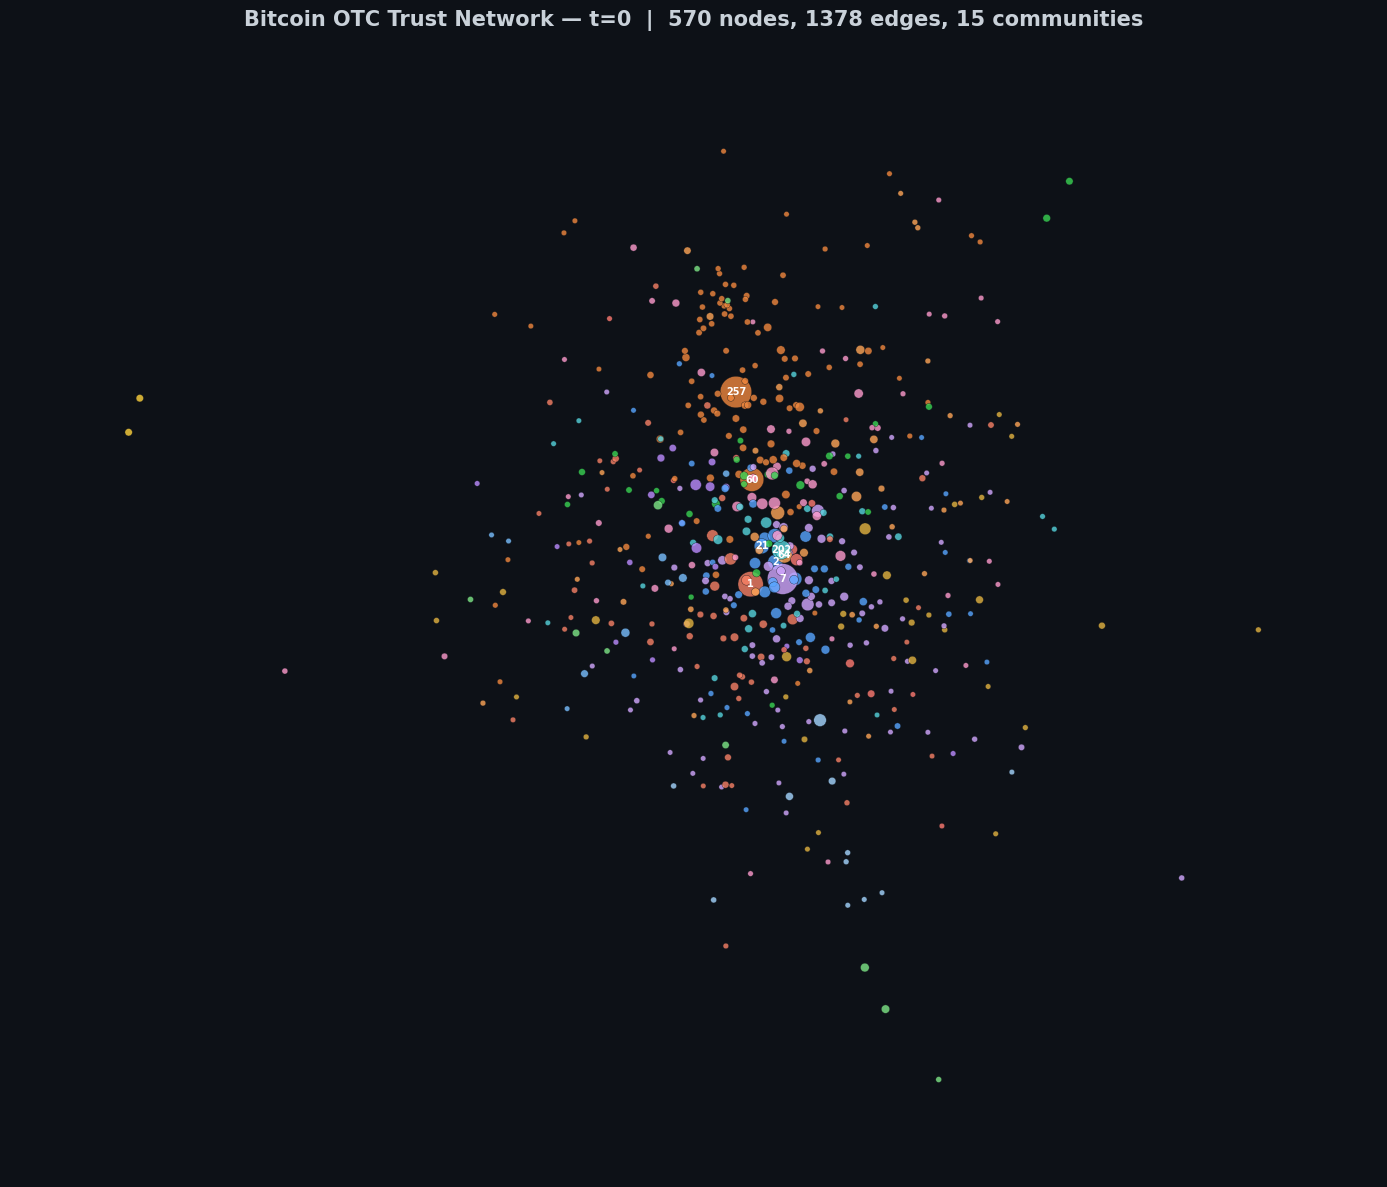

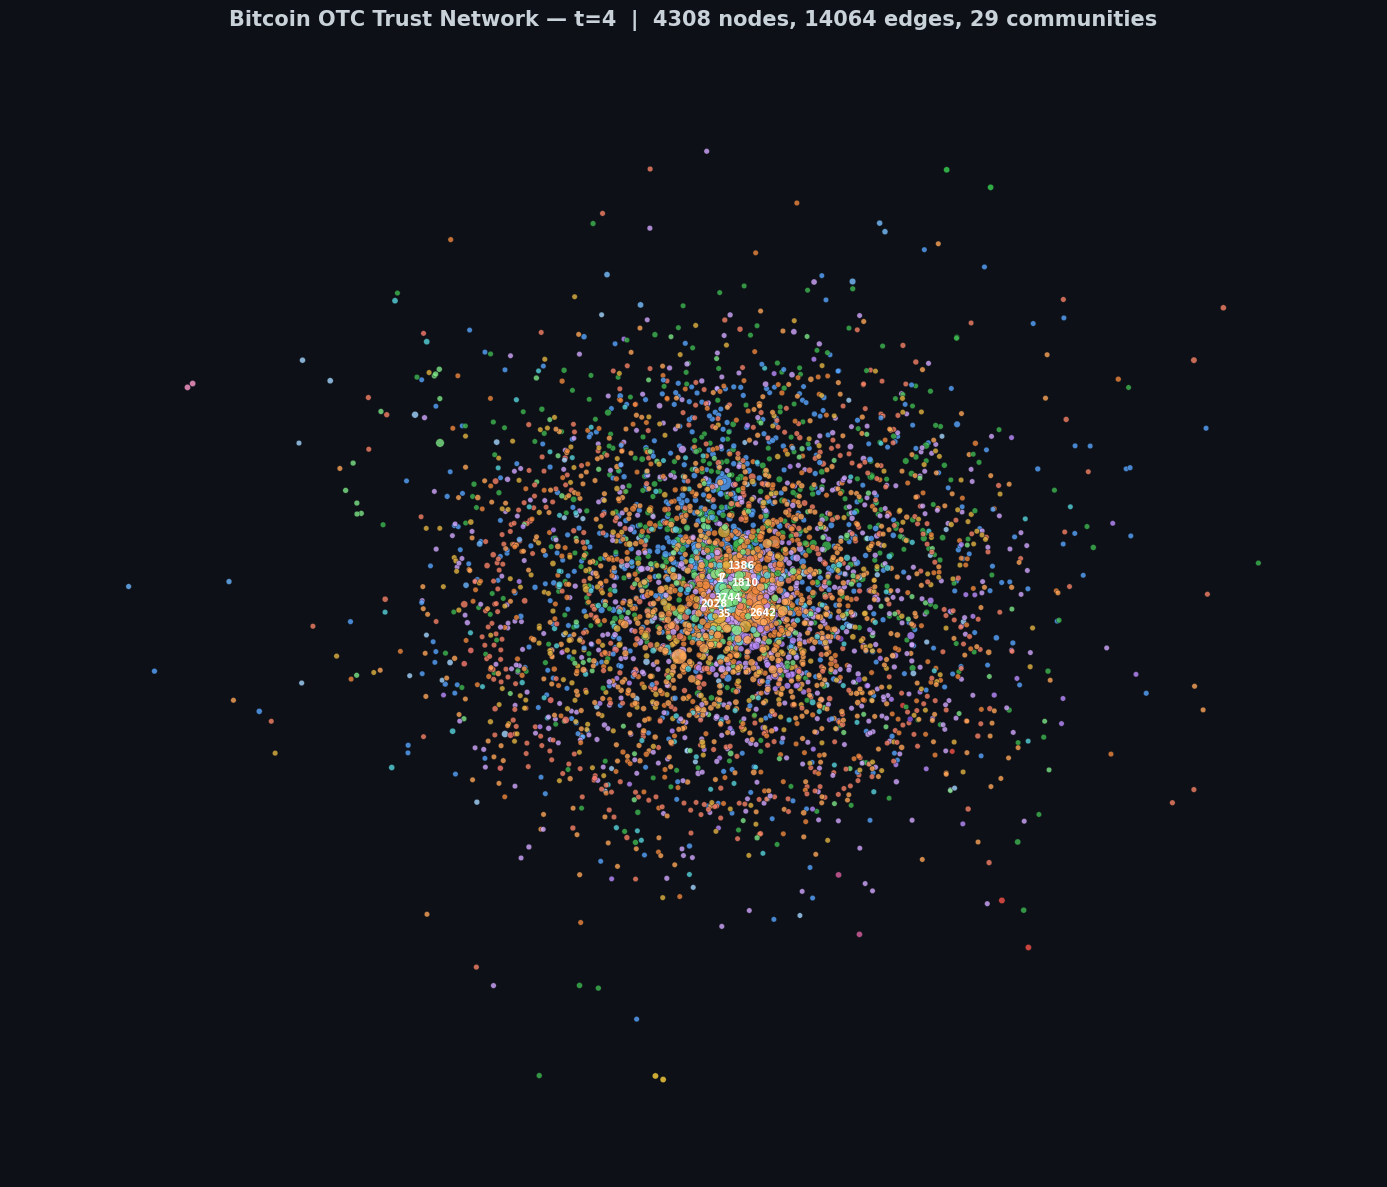

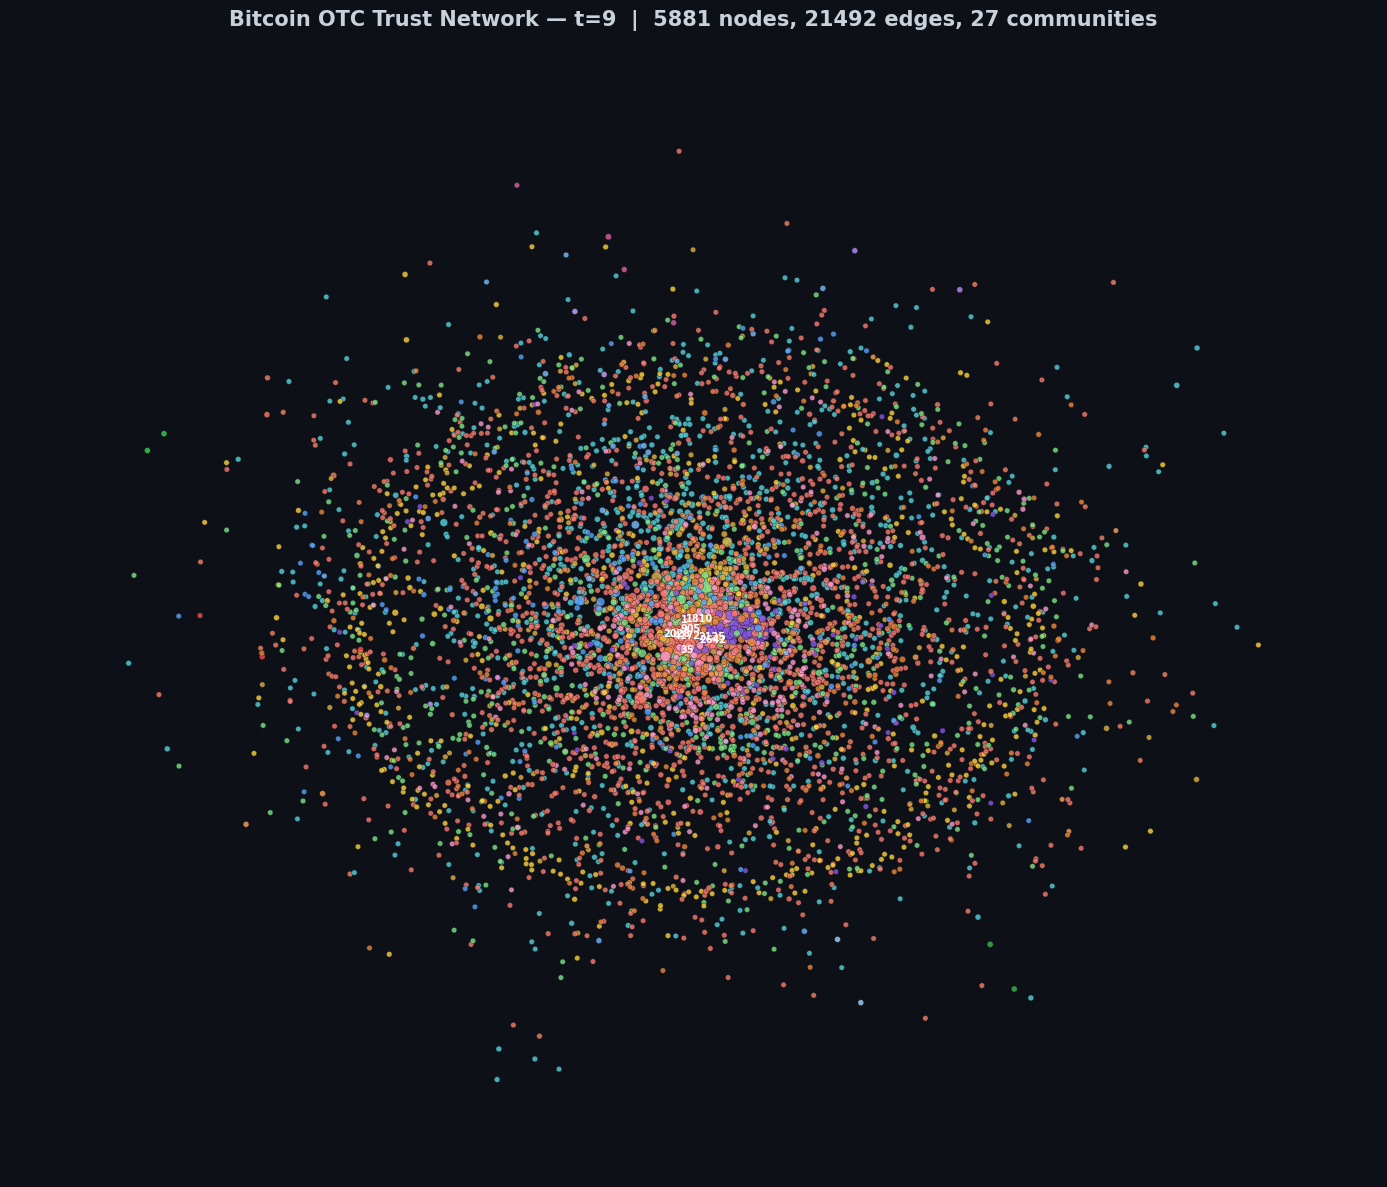

In [20]:
for t_idx in VIS_SNAPSHOT_INDICES:
    G = snapshots[t_idx]
    pr = pagerank_history[t_idx]
    comms = community_history[t_idx]
    H = get_active_subgraph(G)
    
    fig, ax = plt.subplots(1, 1, figsize=(14, 12))
    pos = nx.spring_layout(H, k=2.0/np.sqrt(H.number_of_nodes()), iterations=50, seed=RANDOM_SEED)
    
    pr_vals = [pr.get(n, 0) for n in H.nodes()]
    mn, mx = min(pr_vals), max(pr_vals)
    if mx > mn:
        sizes = [15 + 500 * (pr.get(n, 0) - mn) / (mx - mn) for n in H.nodes()]
    else:
        sizes = [30] * H.number_of_nodes()
    
    cmap = _comm_color_map(comms)
    colors = [cmap.get(comms.get(n, 0), '#58a6ff') for n in H.nodes()]
    
    nx.draw_networkx_edges(H, pos, ax=ax, alpha=0.03, edge_color='#30363d', width=0.3)
    nx.draw_networkx_nodes(H, pos, ax=ax, node_size=sizes, node_color=colors,
                           alpha=0.8, edgecolors='#0d1117', linewidths=0.3)
    
    top_n = sorted(H.nodes(), key=lambda n: pr.get(n, 0), reverse=True)[:8]
    nx.draw_networkx_labels(H, pos, {n: str(n) for n in top_n}, ax=ax,
                            font_size=7, font_color='#ffffff', font_weight='bold')
    
    num_c = len(set(comms.values()))
    ax.set_title(f'Bitcoin OTC Trust Network — t={t_idx}  |  {H.number_of_nodes()} nodes, '
                 f'{H.number_of_edges()} edges, {num_c} communities',
                 fontsize=15, fontweight='bold', pad=20)
    ax.axis('off')
    plt.tight_layout()
    fig.savefig(os.path.join(FIGURES_DIR, f'network_t{t_idx}.png'), dpi=FIGURE_DPI,
                bbox_inches='tight', facecolor=fig.get_facecolor())
    plt.show()

### Influence Heatmap

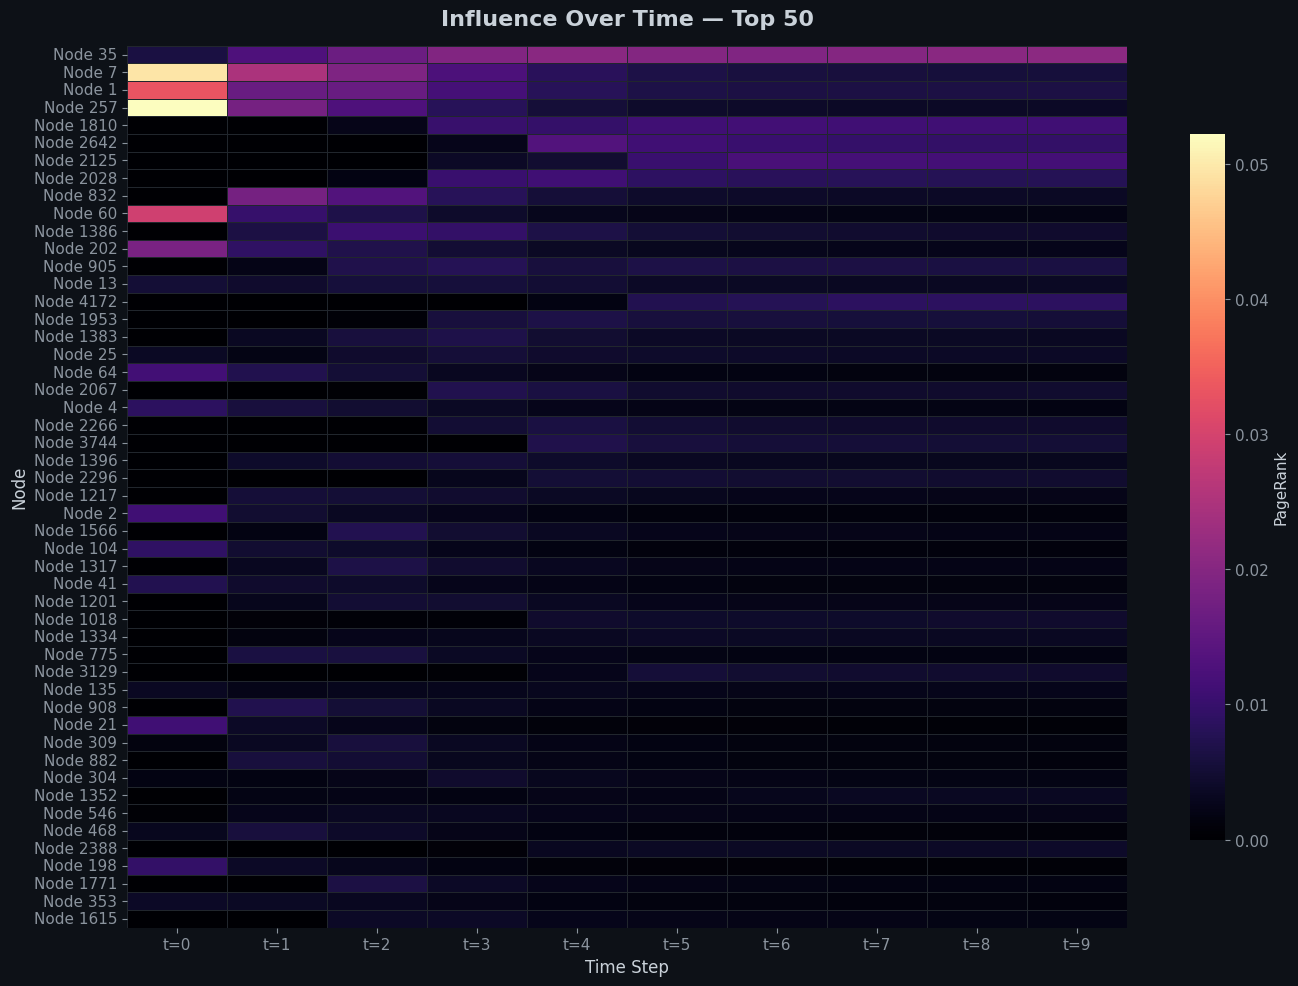

In [21]:
mean_pr = influence_df.mean(axis=1).sort_values(ascending=False)
top_nodes = mean_pr.head(TOP_N_HEATMAP).index
df_top = influence_df.loc[top_nodes]

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(df_top, ax=ax, cmap='magma', linewidths=0.5, linecolor='#21262d',
            cbar_kws={'label': 'PageRank', 'shrink': 0.8},
            xticklabels=[f't={i}' for i in range(df_top.shape[1])],
            yticklabels=[f'Node {n}' for n in df_top.index])
ax.set_title(f'Influence Over Time — Top {TOP_N_HEATMAP}', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Time Step', fontsize=12)
ax.set_ylabel('Node', fontsize=12)
plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, 'influence_heatmap.png'), dpi=FIGURE_DPI,
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

### Ranking & Community Stability

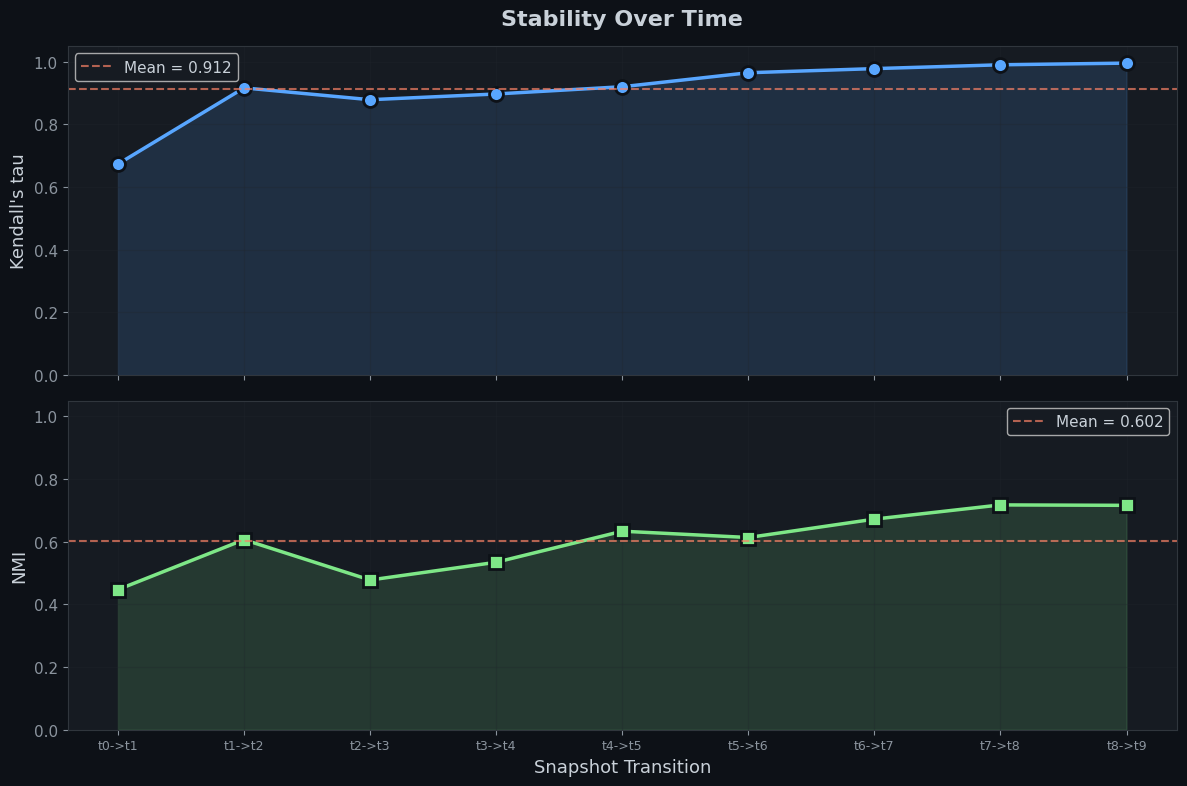

In [22]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
x = list(range(1, len(kendall_tau_scores) + 1))

ax1.plot(x, kendall_tau_scores, 'o-', color='#58a6ff', linewidth=2.5,
         markersize=10, markeredgecolor='#0d1117', markeredgewidth=2)
ax1.fill_between(x, kendall_tau_scores, alpha=0.15, color='#58a6ff')
ax1.set_ylabel("Kendall's tau", fontsize=13)
ax1.set_title('Stability Over Time', fontsize=16, fontweight='bold', pad=15)
ax1.axhline(np.mean(kendall_tau_scores), color='#f78166', linestyle='--',
            alpha=0.7, label=f'Mean = {np.mean(kendall_tau_scores):.3f}')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 1.05)

ax2.plot(x, nmi_scores, 's-', color='#7ee787', linewidth=2.5,
         markersize=10, markeredgecolor='#0d1117', markeredgewidth=2)
ax2.fill_between(x, nmi_scores, alpha=0.15, color='#7ee787')
ax2.set_ylabel('NMI', fontsize=13)
ax2.set_xlabel('Snapshot Transition', fontsize=13)
ax2.axhline(np.mean(nmi_scores), color='#f78166', linestyle='--',
            alpha=0.7, label=f'Mean = {np.mean(nmi_scores):.3f}')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 1.05)
ax2.set_xticks(x)
ax2.set_xticklabels([f't{i-1}->t{i}' for i in x], fontsize=9)

plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, 'rank_stability.png'), dpi=FIGURE_DPI,
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

### Community Evolution

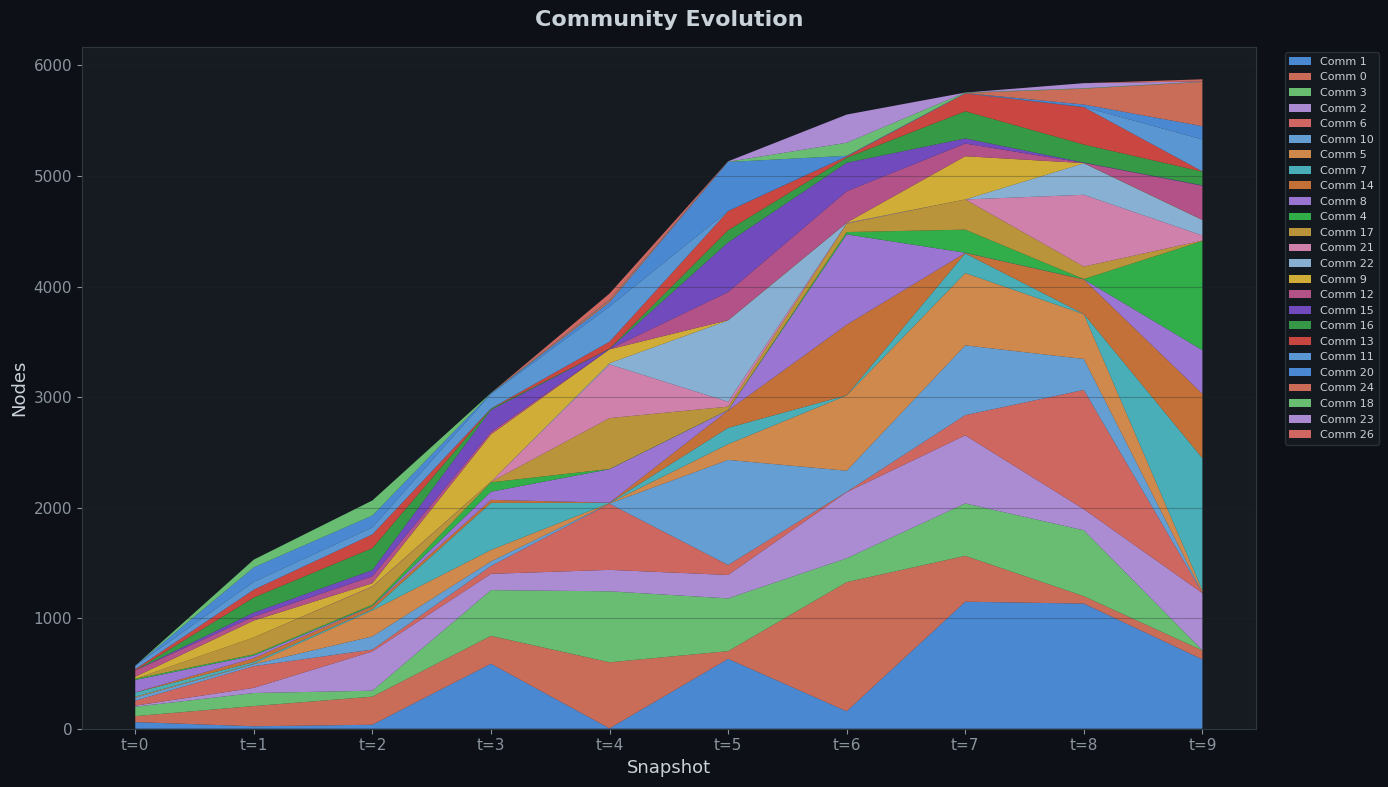

In [23]:
all_comm_ids = set()
for part in community_history:
    all_comm_ids.update(part.values())
all_comm_ids = sorted(all_comm_ids)

comm_size_data = []
for t, part in enumerate(community_history):
    counts = {cid: sum(1 for v in part.values() if v == cid) for cid in all_comm_ids}
    comm_size_data.append(counts)

comm_df = pd.DataFrame(comm_size_data)
keep = [c for c in comm_df.columns if (comm_df[c] > 5).sum() >= 2]
if not keep:
    keep = comm_df.columns[:10]
comm_df = comm_df[keep]
col_order = comm_df.mean().sort_values(ascending=False).index
comm_df = comm_df[col_order]

fig, ax = plt.subplots(figsize=(14, 8))
colors = [COMMUNITY_COLORS[i % len(COMMUNITY_COLORS)] for i in range(len(comm_df.columns))]
ax.stackplot(range(len(comm_df)), [comm_df[c].values for c in comm_df.columns],
             labels=[f'Comm {c}' for c in comm_df.columns], colors=colors, alpha=0.8)
ax.set_title('Community Evolution', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Snapshot', fontsize=13)
ax.set_ylabel('Nodes', fontsize=13)
ax.set_xticks(range(len(comm_df)))
ax.set_xticklabels([f't={i}' for i in range(len(comm_df))])
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=8,
          framealpha=0.8, edgecolor='#30363d')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, 'community_evolution.png'), dpi=FIGURE_DPI,
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

### Community size distribution

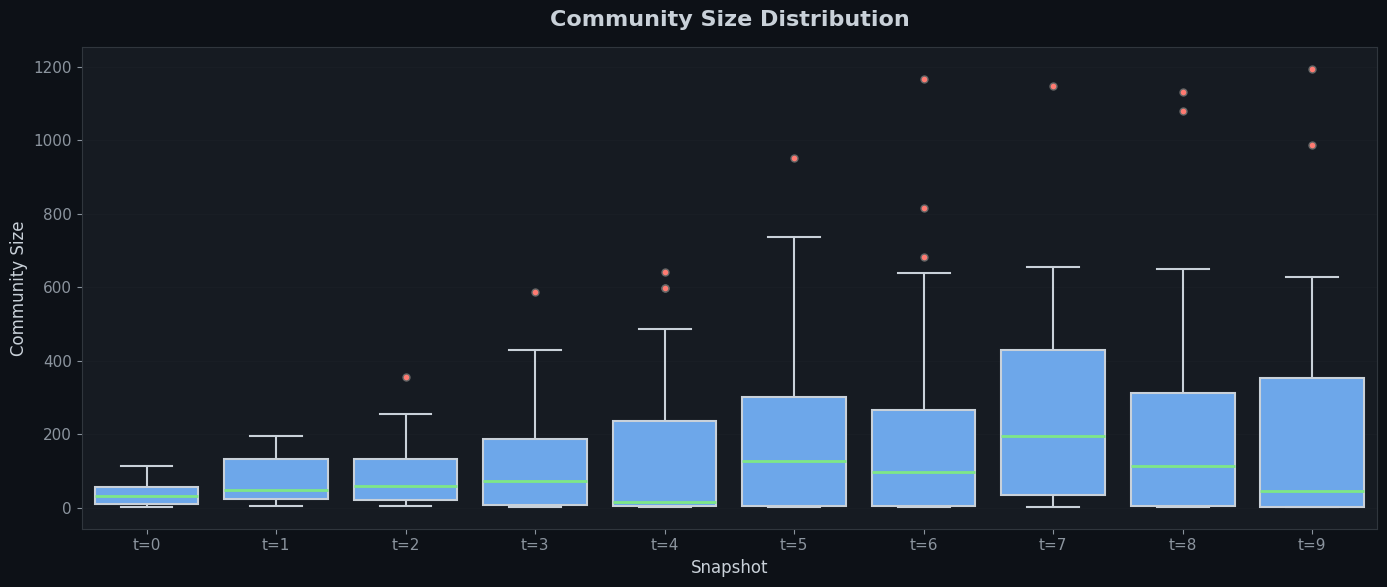

In [24]:
csizes = []
for t, part in enumerate(community_history):
    for size in Counter(part.values()).values():
        csizes.append({'snapshot': f't={t}', 'size': size})

csdf = pd.DataFrame(csizes)

fig, ax = plt.subplots(figsize=(14, 6))
sns.boxplot(data=csdf, x='snapshot', y='size', ax=ax, color='#58a6ff', linewidth=1.5,
            flierprops={'marker': 'o', 'markerfacecolor': '#ff7b72', 'markersize': 5},
            boxprops={'edgecolor': '#c9d1d9'},
            whiskerprops={'color': '#c9d1d9'},
            capprops={'color': '#c9d1d9'},
            medianprops={'color': '#7ee787', 'linewidth': 2})
ax.set_title('Community Size Distribution', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Snapshot', fontsize=12)
ax.set_ylabel('Community Size', fontsize=12)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, 'community_size_boxplot.png'), dpi=FIGURE_DPI,
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

### Modularity over time

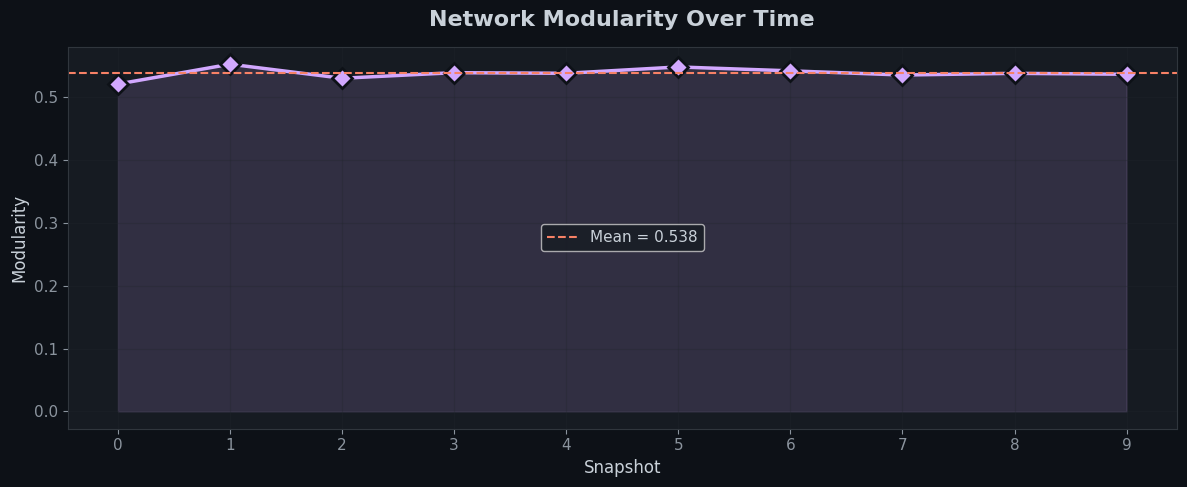

In [25]:
modularity_scores = []
for t, G in enumerate(snapshots):
    H = get_active_subgraph(G)
    part = community_history[t]
    filtered = {n: part[n] for n in H.nodes() if n in part}
    mod = community_louvain.modularity(filtered, H) if filtered else 0.0
    modularity_scores.append(mod)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(range(NUM_SNAPSHOTS), modularity_scores, 'D-', color='#d2a8ff',
        linewidth=2.5, markersize=10, markeredgecolor='#0d1117', markeredgewidth=2)
ax.fill_between(range(NUM_SNAPSHOTS), modularity_scores, alpha=0.15, color='#d2a8ff')
ax.axhline(np.mean(modularity_scores), color='#f78166', linestyle='--',
           label=f'Mean = {np.mean(modularity_scores):.3f}')
ax.set_xlabel('Snapshot', fontsize=12)
ax.set_ylabel('Modularity', fontsize=12)
ax.set_title('Network Modularity Over Time', fontsize=16, fontweight='bold', pad=15)
ax.set_xticks(range(NUM_SNAPSHOTS))
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, 'modularity_over_time.png'), dpi=FIGURE_DPI,
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

### Embedding Space — First vs Last Snapshot

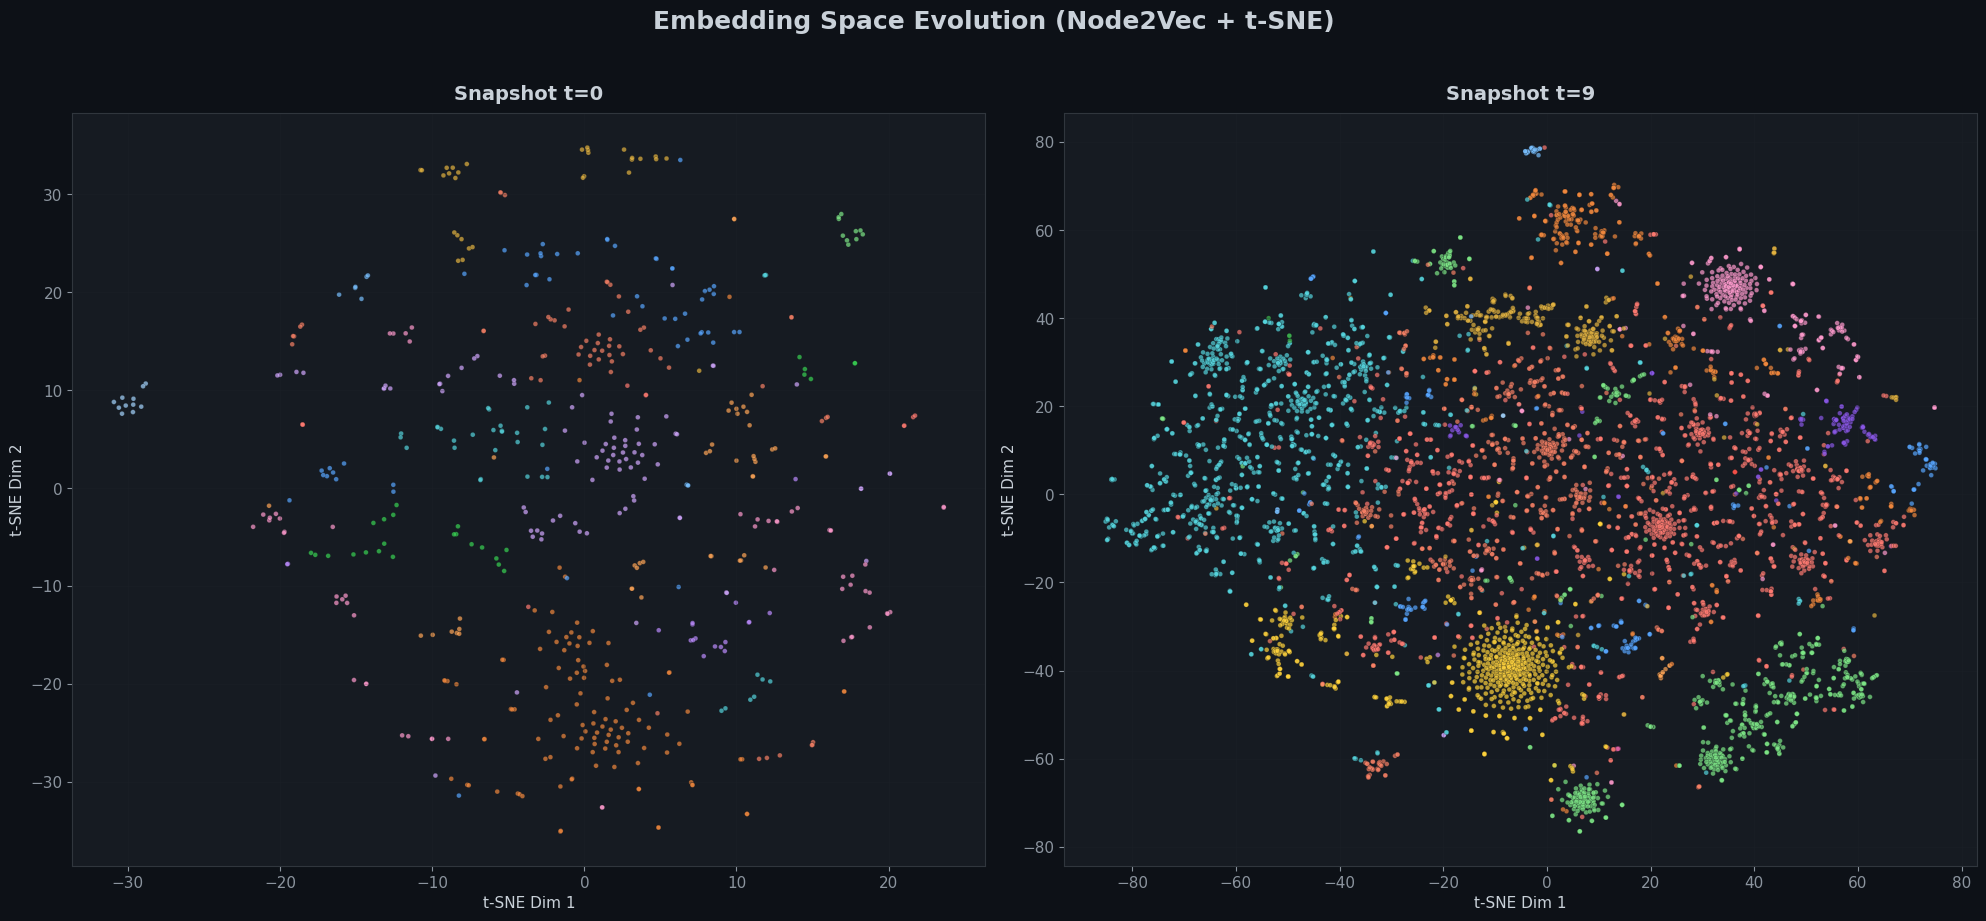

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(20, 9))
datasets = [
    (embeddings_all[0], community_history[0], 'Snapshot t=0', axes[0]),
    (embeddings_all[-1], community_history[-1], f'Snapshot t={NUM_SNAPSHOTS-1}', axes[1]),
]

for emb, comms, title, ax in datasets:
    if not emb:
        ax.set_title(f'{title} (no embeddings)', fontsize=14, fontweight='bold')
        continue
    nodes, coords = reduce_embeddings_tsne(emb)
    cmap = _comm_color_map(comms)
    colors = [cmap.get(comms.get(n, 0), '#58a6ff') for n in nodes]
    ax.scatter(coords[:, 0], coords[:, 1], c=colors, s=12, alpha=0.7,
               edgecolors='#0d1117', linewidths=0.2)
    ax.set_title(title, fontsize=14, fontweight='bold', pad=10)
    ax.set_xlabel('t-SNE Dim 1', fontsize=11)
    ax.set_ylabel('t-SNE Dim 2', fontsize=11)
    ax.grid(True, alpha=0.2)

fig.suptitle('Embedding Space Evolution (Node2Vec + t-SNE)',
             fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, 'embedding_drift.png'), dpi=FIGURE_DPI,
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

### Embedding drift — who moved the most?

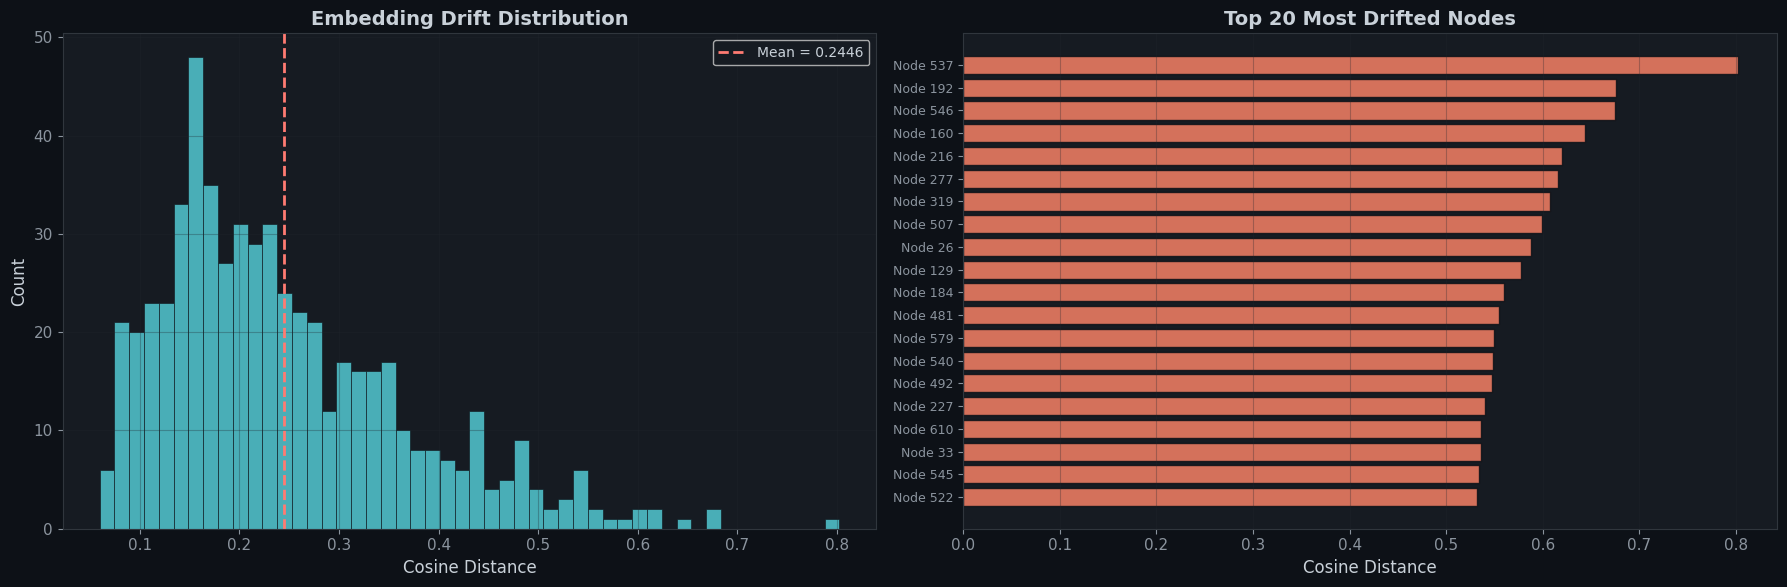

In [29]:
if embeddings_all[0] and embeddings_all[-1]:
    drift = compute_embedding_drift(embeddings_all[0], embeddings_all[-1])
    drift_vals = list(drift.values())
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
    
    ax1.hist(drift_vals, bins=50, color='#56d4dd', alpha=0.8, edgecolor='#0d1117', linewidth=0.5)
    ax1.axvline(np.mean(drift_vals), color='#ff7b72', linestyle='--', linewidth=2,
                label=f'Mean = {np.mean(drift_vals):.4f}')
    ax1.set_xlabel('Cosine Distance', fontsize=12)
    ax1.set_ylabel('Count', fontsize=12)
    ax1.set_title('Embedding Drift Distribution', fontsize=14, fontweight='bold')
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3)
    
    sorted_drift = sorted(drift.items(), key=lambda x: x[1], reverse=True)[:20]
    nodes_d, vals_d = zip(*sorted_drift)
    ax2.barh(range(len(nodes_d)), vals_d, color='#f78166', alpha=0.85,
             edgecolor='#0d1117', linewidth=1)
    ax2.set_yticks(range(len(nodes_d)))
    ax2.set_yticklabels([f'Node {n}' for n in nodes_d], fontsize=9)
    ax2.invert_yaxis()
    ax2.set_xlabel('Cosine Distance', fontsize=12)
    ax2.set_title('Top 20 Most Drifted Nodes', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3, axis='x')
    
    plt.tight_layout()
    fig.savefig(os.path.join(FIGURES_DIR, 'embedding_drift_distribution.png'), dpi=FIGURE_DPI,
                bbox_inches='tight', facecolor=fig.get_facecolor())
    plt.show()

### Embedding drift vs PageRank change

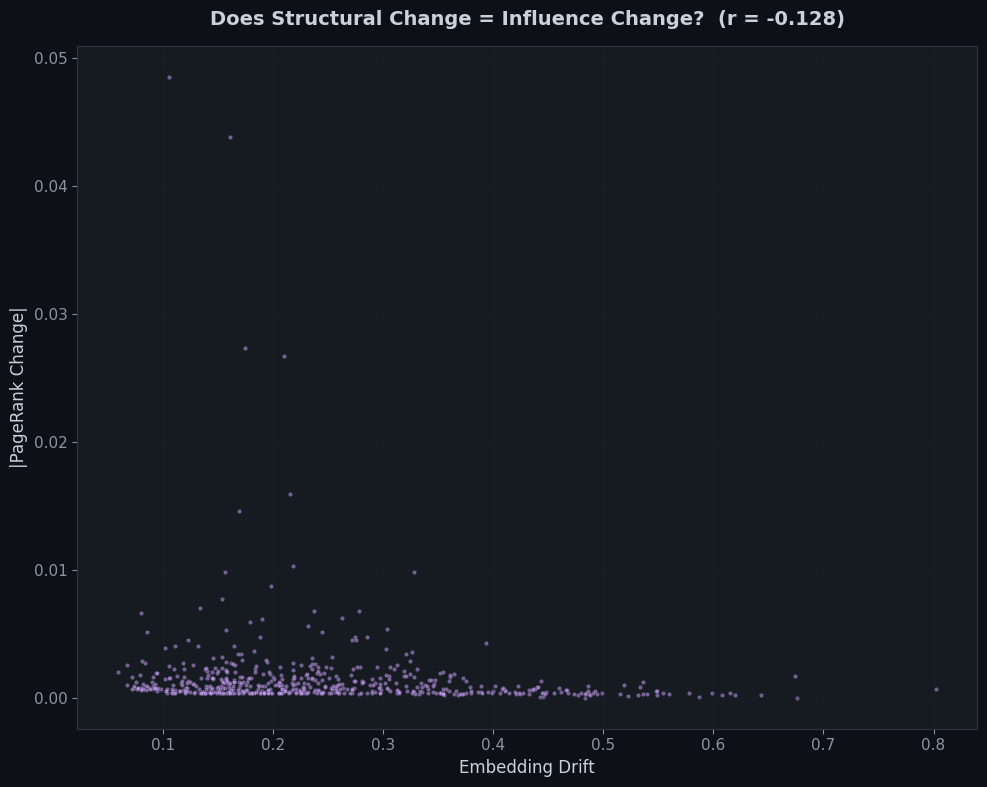

In [30]:
if embeddings_all[0] and embeddings_all[-1]:
    drift = compute_embedding_drift(embeddings_all[0], embeddings_all[-1])
    pr_first, pr_last = pagerank_history[0], pagerank_history[-1]
    common = sorted(set(drift.keys()) & set(pr_first.keys()) & set(pr_last.keys()))
    
    drift_arr = np.array([drift[n] for n in common])
    pr_change = np.array([abs(pr_last.get(n, 0) - pr_first.get(n, 0)) for n in common])
    
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.scatter(drift_arr, pr_change, s=10, alpha=0.5, color='#d2a8ff',
               edgecolors='#0d1117', linewidths=0.3)
    corr = np.corrcoef(drift_arr, pr_change)[0, 1]
    ax.set_xlabel('Embedding Drift', fontsize=12)
    ax.set_ylabel('|PageRank Change|', fontsize=12)
    ax.set_title(f'Does Structural Change = Influence Change?  (r = {corr:.3f})',
                 fontsize=14, fontweight='bold', pad=15)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    fig.savefig(os.path.join(FIGURES_DIR, 'drift_vs_pagerank_change.png'), dpi=FIGURE_DPI,
                bbox_inches='tight', facecolor=fig.get_facecolor())
    plt.show()

### Top Influencers Dashboard

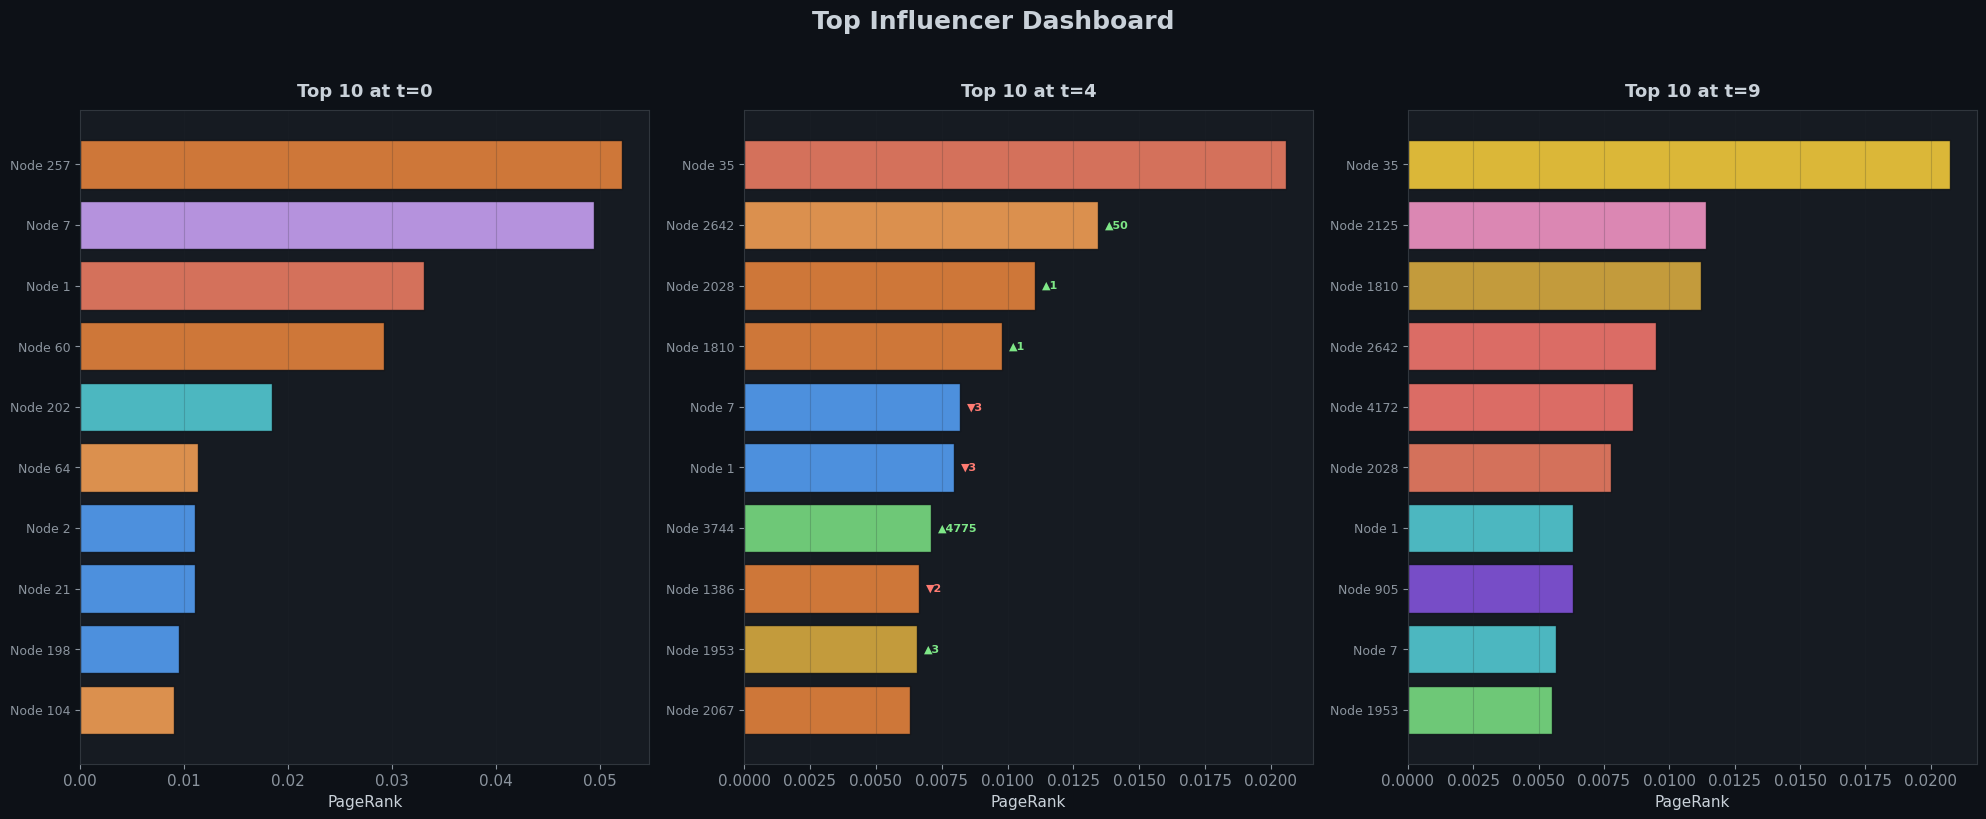

In [31]:
fig, axes = plt.subplots(1, len(VIS_SNAPSHOT_INDICES), figsize=(20, 8))
if len(VIS_SNAPSHOT_INDICES) == 1:
    axes = [axes]

for idx, t in enumerate(VIS_SNAPSHOT_INDICES):
    ax = axes[idx]
    col = f't{t}'
    if col not in influence_df.columns:
        continue
    top = influence_df[col].sort_values(ascending=False).head(TOP_N_DASHBOARD)
    node_ids, scores = top.index.tolist(), top.values
    comms = community_history[t]
    cmap = _comm_color_map(comms)
    bar_colors = [cmap.get(comms.get(n, 0), '#58a6ff') for n in node_ids]
    
    ax.barh(range(len(node_ids)), scores, color=bar_colors, alpha=0.85,
            edgecolor='#0d1117', linewidth=1)
    ax.set_yticks(range(len(node_ids)))
    ax.set_yticklabels([f'Node {n}' for n in node_ids], fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel('PageRank', fontsize=11)
    ax.set_title(f'Top {TOP_N_DASHBOARD} at t={t}', fontsize=13, fontweight='bold', pad=10)
    ax.grid(True, alpha=0.2, axis='x')
    
    if t > 0:
        prev_col = f't{t-1}'
        if prev_col in influence_df.columns:
            prev_ranks = {node: rank for rank, node in enumerate(
                influence_df[prev_col].sort_values(ascending=False).index)}
            for i, node in enumerate(node_ids):
                prev_rank = prev_ranks.get(node)
                if prev_rank is not None:
                    change = prev_rank - i
                    if change > 0:
                        ax.annotate(f'▲{change}', xy=(scores[i], i), xytext=(5, 0),
                                    textcoords='offset points', fontsize=8,
                                    color='#7ee787', fontweight='bold', va='center')
                    elif change < 0:
                        ax.annotate(f'▼{abs(change)}', xy=(scores[i], i), xytext=(5, 0),
                                    textcoords='offset points', fontsize=8,
                                    color='#ff7b72', fontweight='bold', va='center')

fig.suptitle('Top Influencer Dashboard', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, 'top_influencers.png'), dpi=FIGURE_DPI,
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

### Most volatile nodes

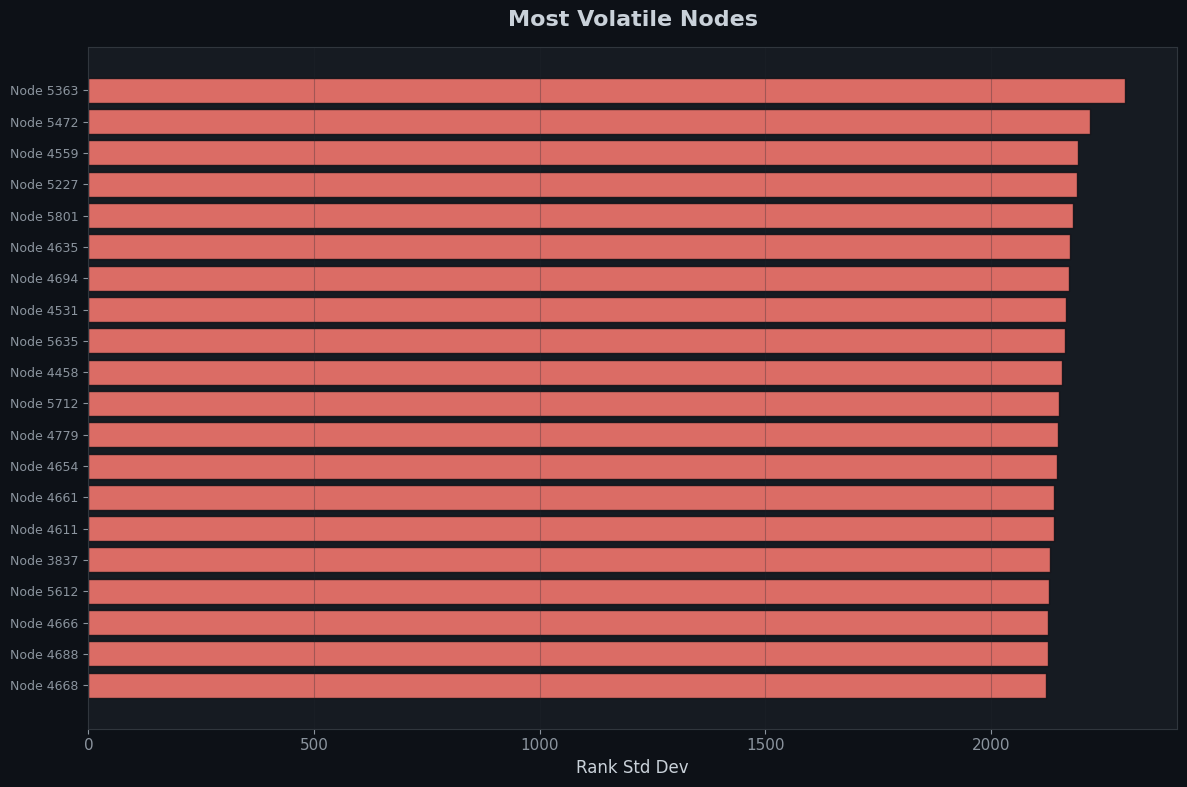

In [32]:
rank_df = influence_df.rank(ascending=False)
rank_std = rank_df.std(axis=1).sort_values(ascending=False)
top_volatile = rank_std.head(20)

fig, ax = plt.subplots(figsize=(12, 8))
colors_vol = ['#ff7b72' if v > rank_std.quantile(0.95) else '#ffa657' for v in top_volatile.values]
ax.barh(range(len(top_volatile)), top_volatile.values, color=colors_vol,
        alpha=0.85, edgecolor='#0d1117', linewidth=1)
ax.set_yticks(range(len(top_volatile)))
ax.set_yticklabels([f'Node {n}' for n in top_volatile.index], fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Rank Std Dev', fontsize=12)
ax.set_title('Most Volatile Nodes', fontsize=16, fontweight='bold', pad=15)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, 'most_volatile_nodes.png'), dpi=FIGURE_DPI,
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

### NDCG Quality Scores

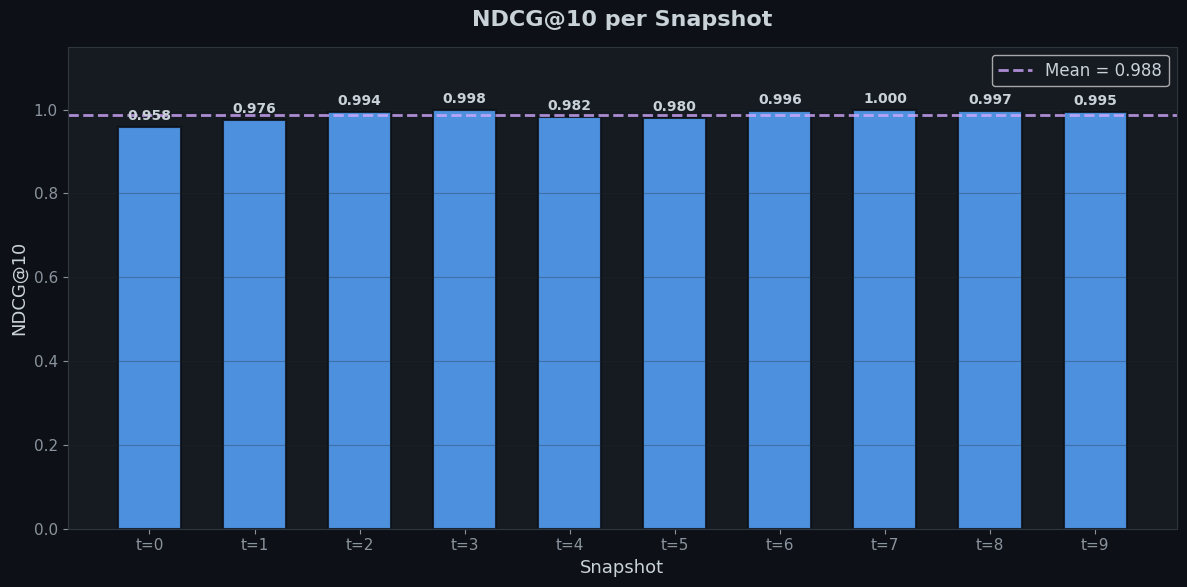

In [33]:
fig, ax = plt.subplots(figsize=(12, 6))
x = range(len(ndcg_scores))
colors = ['#58a6ff' if s >= 0.8 else '#ffa657' if s >= 0.6 else '#ff7b72' for s in ndcg_scores]
bars = ax.bar(x, ndcg_scores, color=colors, alpha=0.85, edgecolor='#0d1117', linewidth=1.5, width=0.6)
ax.axhline(np.mean(ndcg_scores), color='#d2a8ff', linestyle='--', linewidth=2,
           alpha=0.8, label=f'Mean = {np.mean(ndcg_scores):.3f}')
for bar, score in zip(bars, ndcg_scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{score:.3f}', ha='center', va='bottom', fontsize=10,
            fontweight='bold', color='#c9d1d9')
ax.set_title(f'NDCG@{NDCG_K} per Snapshot', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Snapshot', fontsize=13)
ax.set_ylabel(f'NDCG@{NDCG_K}', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels([f't={i}' for i in x])
ax.set_ylim(0, 1.15)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, 'ndcg_scores.png'), dpi=FIGURE_DPI,
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

### All metrics side by side

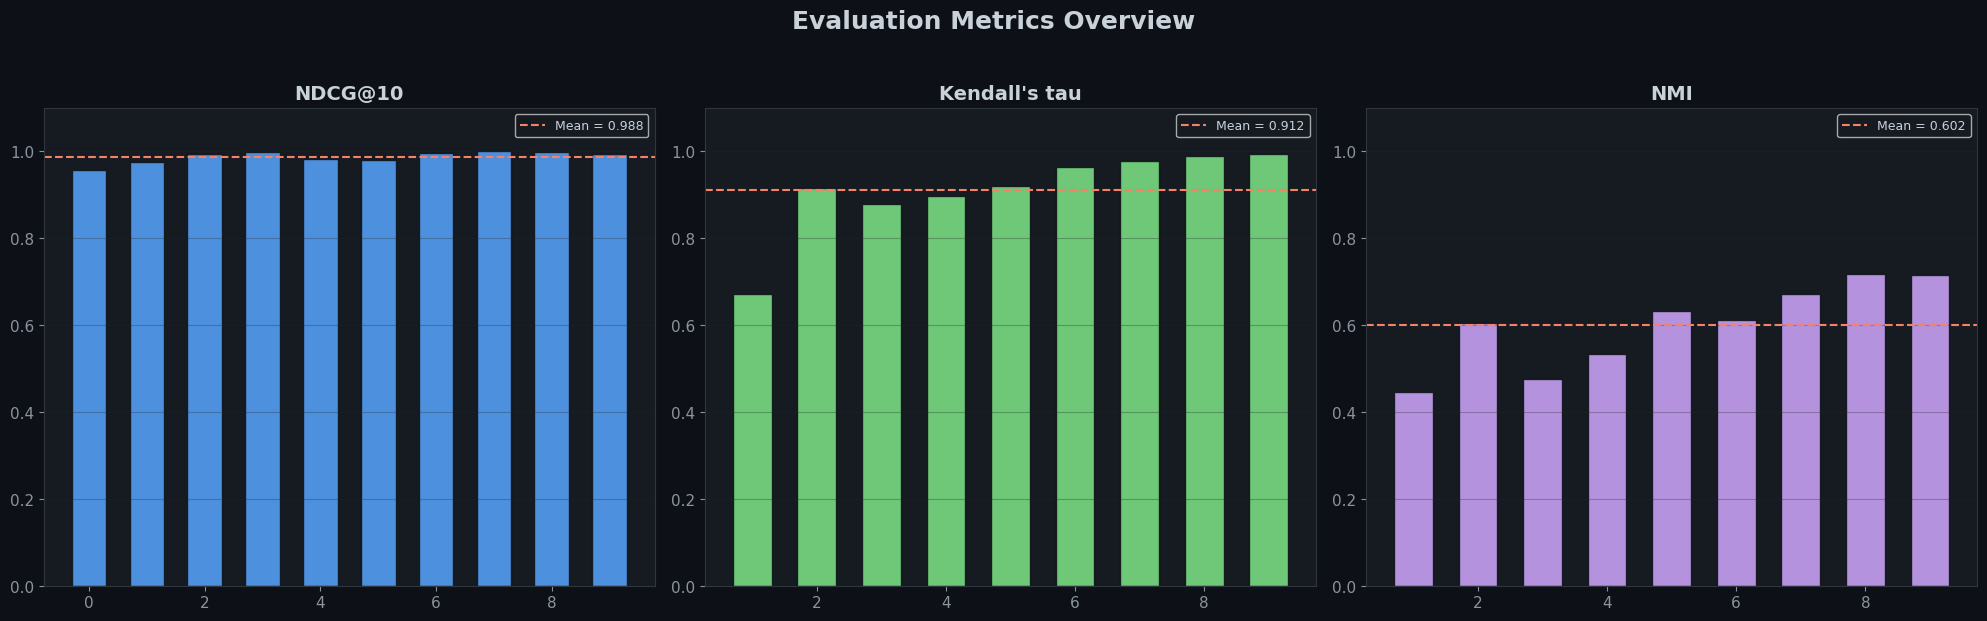

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

axes[0].bar(range(NUM_SNAPSHOTS), ndcg_scores, color='#58a6ff', alpha=0.85, edgecolor='#0d1117', width=0.6)
axes[0].axhline(np.mean(ndcg_scores), color='#f78166', linestyle='--', label=f'Mean = {np.mean(ndcg_scores):.3f}')
axes[0].set_title(f'NDCG@{NDCG_K}', fontsize=14, fontweight='bold')
axes[0].set_ylim(0, 1.1)
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3, axis='y')

axes[1].bar(range(1, NUM_SNAPSHOTS), kendall_tau_scores, color='#7ee787', alpha=0.85, edgecolor='#0d1117', width=0.6)
axes[1].axhline(np.mean(kendall_tau_scores), color='#f78166', linestyle='--', label=f'Mean = {np.mean(kendall_tau_scores):.3f}')
axes[1].set_title("Kendall's tau", fontsize=14, fontweight='bold')
axes[1].set_ylim(0, 1.1)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3, axis='y')

axes[2].bar(range(1, NUM_SNAPSHOTS), nmi_scores, color='#d2a8ff', alpha=0.85, edgecolor='#0d1117', width=0.6)
axes[2].axhline(np.mean(nmi_scores), color='#f78166', linestyle='--', label=f'Mean = {np.mean(nmi_scores):.3f}')
axes[2].set_title('NMI', fontsize=14, fontweight='bold')
axes[2].set_ylim(0, 1.1)
axes[2].legend(fontsize=9)
axes[2].grid(True, alpha=0.3, axis='y')

fig.suptitle('Evaluation Metrics Overview', fontsize=18, fontweight='bold', y=1.03)
plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, 'evaluation_overview.png'), dpi=FIGURE_DPI,
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

---
## What Did We Find?

In [35]:
print('Top 15 Most Influential Nodes (by average PageRank):')
print('=' * 55)
mean_pr = influence_df.mean(axis=1).sort_values(ascending=False)
rank_df = influence_df.rank(ascending=False, axis=0)
rank_std = rank_df.std(axis=1)
for rank, (node, score) in enumerate(mean_pr.head(15).items(), 1):
    std = rank_std.get(node, 0)
    print(f'  #{rank:2d}  Node {node:<6d}  Mean PR = {score:.6f}  Rank StdDev = {std:.1f}')

Top 15 Most Influential Nodes (by average PageRank):
  # 1  Node 35      Mean PR = 0.017558  Rank StdDev = 5.7
  # 2  Node 7       Mean PR = 0.014391  Rank StdDev = 3.7
  # 3  Node 1       Mean PR = 0.011734  Rank StdDev = 2.3
  # 4  Node 257     Mean PR = 0.011533  Rank StdDev = 7.8
  # 5  Node 1810    Mean PR = 0.007810  Rank StdDev = 1464.7
  # 6  Node 2642    Mean PR = 0.006612  Rank StdDev = 1762.6
  # 7  Node 2125    Mean PR = 0.006548  Rank StdDev = 1763.8
  # 8  Node 2028    Mean PR = 0.006392  Rank StdDev = 1462.3
  # 9  Node 832     Mean PR = 0.006378  Rank StdDev = 1015.7
  #10  Node 60      Mean PR = 0.006322  Rank StdDev = 19.5
  #11  Node 1386    Mean PR = 0.005642  Rank StdDev = 1016.6
  #12  Node 202     Mean PR = 0.005637  Rank StdDev = 11.4
  #13  Node 905     Mean PR = 0.005495  Rank StdDev = 1015.4
  #14  Node 13      Mean PR = 0.004350  Rank StdDev = 5.1
  #15  Node 4172    Mean PR = 0.004301  Rank StdDev = 2000.3


In [36]:
first_col, last_col = influence_df.columns[0], influence_df.columns[-1]
rank_first = influence_df[first_col].rank(ascending=False)
rank_last = influence_df[last_col].rank(ascending=False)
rank_change = (rank_first - rank_last).dropna()

print('Biggest Risers:')
print('-' * 45)
for node, change in rank_change.sort_values(ascending=False).head(10).items():
    print(f'  Node {node:<6d}  climbed {change:.0f} ranks  (now #{rank_last[node]:.0f})')
print()
print('Biggest Fallers:')
print('-' * 45)
for node, change in rank_change.sort_values(ascending=True).head(10).items():
    print(f'  Node {node:<6d}  dropped {abs(change):.0f} ranks  (now #{rank_last[node]:.0f})')

Biggest Risers:
---------------------------------------------
  Node 2125    climbed 3224 ranks  (now #2)
  Node 1810    climbed 3223 ranks  (now #3)
  Node 2642    climbed 3222 ranks  (now #4)
  Node 4172    climbed 3221 ranks  (now #5)
  Node 2028    climbed 3220 ranks  (now #6)
  Node 905     climbed 3218 ranks  (now #8)
  Node 1953    climbed 3216 ranks  (now #10)
  Node 3744    climbed 3215 ranks  (now #11)
  Node 2296    climbed 3214 ranks  (now #12)
  Node 2067    climbed 3213 ranks  (now #13)

Biggest Fallers:
---------------------------------------------
  Node 355     dropped 5350 ranks  (now #5836)
  Node 303     dropped 5350 ranks  (now #5836)
  Node 187     dropped 5350 ranks  (now #5836)
  Node 382     dropped 5344 ranks  (now #5806)
  Node 291     dropped 5272 ranks  (now #5735)
  Node 450     dropped 5270 ranks  (now #5760)
  Node 196     dropped 5219 ranks  (now #5786)
  Node 434     dropped 5210 ranks  (now #5716)
  Node 290     dropped 5210 ranks  (now #5716)
  Node 

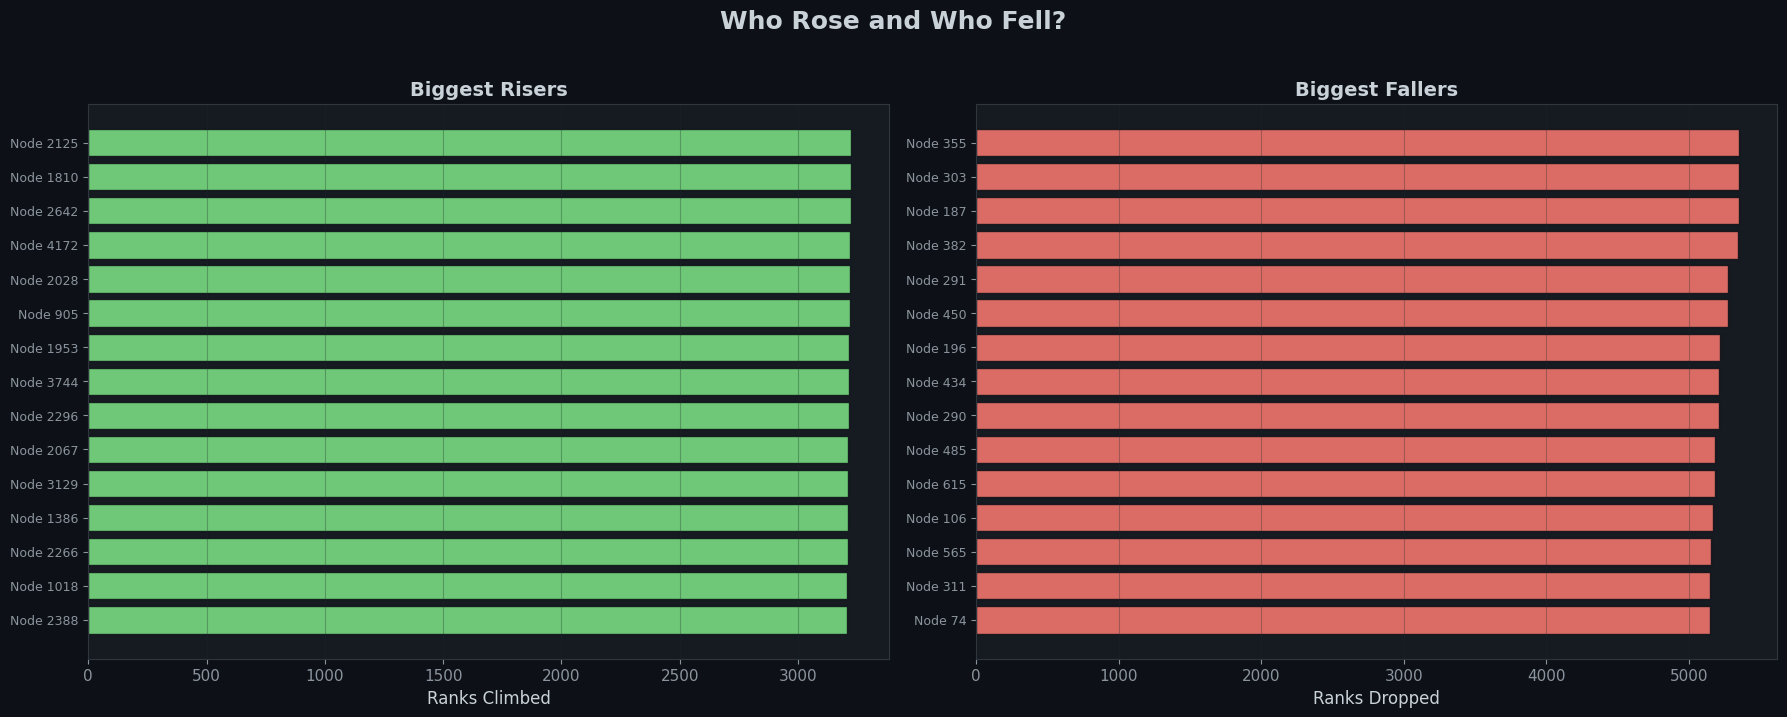

In [37]:
# risers vs fallers chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

risers = rank_change.sort_values(ascending=False).head(15)
ax1.barh(range(len(risers)), risers.values, color='#7ee787', alpha=0.85, edgecolor='#0d1117')
ax1.set_yticks(range(len(risers)))
ax1.set_yticklabels([f'Node {n}' for n in risers.index], fontsize=9)
ax1.invert_yaxis()
ax1.set_xlabel('Ranks Climbed', fontsize=12)
ax1.set_title('Biggest Risers', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='x')

fallers = rank_change.sort_values(ascending=True).head(15)
ax2.barh(range(len(fallers)), fallers.values.astype(float) * -1, color='#ff7b72', alpha=0.85, edgecolor='#0d1117')
ax2.set_yticks(range(len(fallers)))
ax2.set_yticklabels([f'Node {n}' for n in fallers.index], fontsize=9)
ax2.invert_yaxis()
ax2.set_xlabel('Ranks Dropped', fontsize=12)
ax2.set_title('Biggest Fallers', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='x')

fig.suptitle('Who Rose and Who Fell?', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, 'risers_and_fallers.png'), dpi=FIGURE_DPI,
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

In [38]:
print('\nFull Metrics Summary:')
print('=' * 85)
print(summary_df.to_string(index=False, float_format='%.4f'))
print('=' * 85)

metrics_path = os.path.join(OUTPUT_DIR, 'metrics.csv')
summary_df.to_csv(metrics_path, index=False)
print(f'\nMetrics saved to {metrics_path}')


Full Metrics Summary:
 snapshot   ndcg  kendall_tau    nmi  num_nodes  num_edges  num_communities
        0 0.9581          NaN    NaN        570       1378               15
        1 0.9761       0.6729 0.4469       1555       4159               21
        2 0.9944       0.9159 0.6061       2070       5983               22
        3 0.9981       0.8782 0.4775       3040       9729               22
        4 0.9818       0.8965 0.5342       4308      14064               29
        5 0.9800       0.9196 0.6332       5137      18092               24
        6 0.9962       0.9642 0.6131       5558      19890               24
        7 0.9998       0.9773 0.6717       5757      20893               20
        8 0.9974       0.9896 0.7171       5844      21314               25
        9 0.9949       0.9949 0.7157       5881      21492               27

Metrics saved to c:\Users\ASUS\Documents\projects\something-graph\output\metrics.csv


---
## Wrapping Up

In [40]:
mean_ndcg = np.mean(ndcg_scores)
mean_tau = np.mean(kendall_tau_scores)
mean_nmi_val = np.mean(nmi_scores)

print('CONCLUSIONS')
print('=' * 70)
print()

if mean_ndcg > 0.8:
    print(f'1. Ranking Quality (NDCG@{NDCG_K} = {mean_ndcg:.4f}):')
    print('   PageRank aligns strongly with the composite ground truth.')
elif mean_ndcg > 0.6:
    print(f'1. Ranking Quality (NDCG@{NDCG_K} = {mean_ndcg:.4f}):')
    print('   Moderate — captures the big picture but misses some nuances.')
else:
    print(f'1. Ranking Quality (NDCG@{NDCG_K} = {mean_ndcg:.4f}):')
    print('   Limited — influence here is multi-dimensional.')

print()
if mean_tau > 0.8:
    print(f'2. Ranking Stability (Kendall tau = {mean_tau:.4f}):')
    print('   Very stable influence hierarchy.')
elif mean_tau > 0.5:
    print(f'2. Ranking Stability (Kendall tau = {mean_tau:.4f}):')
    print('   Moderate — real shifts happening but overall structure persists.')
else:
    print(f'2. Ranking Stability (Kendall tau = {mean_tau:.4f}):')
    print('   Volatile — rankings reshuffling significantly each step.')

print()
if mean_nmi_val > 0.7:
    print(f'3. Community Consistency (NMI = {mean_nmi_val:.4f}):')
    print('   Communities well-preserved through evolution.')
elif mean_nmi_val > 0.4:
    print(f'3. Community Consistency (NMI = {mean_nmi_val:.4f}):')
    print('   Moderate persistence with ongoing reorganization.')
else:
    print(f'3. Community Consistency (NMI = {mean_nmi_val:.4f}):')
    print('   Fluid structure — lots of restructuring each step.')

print()
print('4. Embeddings: Node2Vec + Procrustes alignment captures structural drift.')
print()
print('=' * 70)

CONCLUSIONS

1. Ranking Quality (NDCG@10 = 0.9877):
   PageRank aligns strongly with the composite ground truth.

2. Ranking Stability (Kendall tau = 0.9121):
   Very stable influence hierarchy.

3. Community Consistency (NMI = 0.6017):
   Moderate persistence with ongoing reorganization.

4. Embeddings: Node2Vec + Procrustes alignment captures structural drift.

